**Experiment A**

In [ ]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy

import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt


# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def cleanup_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
# Cell 3 — Dataset: Fashion-MNIST + loaders
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]

train: 60000 test: 10000


In [ ]:
# Cell 4 — PUBLIC set + IID clients
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [
        perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
        for i in range(num_clients)
    ]

clients = build_iid_clients_from_indices(
    avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0
)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 59800
NUM_CLIENTS: 5980 | samples/client: 10 | clients/round: 100
q = 0.016722408026755852


/tmp/ipykernel_764/2050036623.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  targets = np.array(dataset.targets)


In [ ]:
# Cell 4b — OPTIONAL speed-up (added Sep 2026): cache the datasets as tensors once.
# client_update() builds a new DataLoader per client per round and re-applies ToTensor/Normalize to
# every image on every access; with 100 clients x 180 rounds that CPU work, not the GPU, dominates the
# run time.  Caching applies the same transforms exactly once, so every sample tensor is identical and
# the training numbers are unchanged; runs are typically 1.5-2x faster.  Set to False to disable.
USE_CACHED_TENSORS = True
if USE_CACHED_TENSORS:
    from torch.utils.data import TensorDataset
    class _CachedDS(TensorDataset):
        def __init__(self, ds):
            xs, ys = [], []
            for x, y in DataLoader(ds, batch_size=1024, shuffle=False, num_workers=0):
                xs.append(x); ys.append(y)
            X, Y = torch.cat(xs), torch.cat(ys)
            super().__init__(X, Y)
            self.targets = Y.tolist()
    train_ds = _CachedDS(train_ds)
    test_ds = _CachedDS(test_ds)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)
    print("cached tensors -> train:", tuple(train_ds.tensors[0].shape), "test:", tuple(test_ds.tensors[0].shape))


cached tensors -> train: (60000, 1, 28, 28) test: (10000, 1, 28, 28)


In [ ]:
# Cell 6 — Model + evaluation
class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [ ]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a * b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out

In [ ]:
# Cell 8 — Local client update
# Local client update (SGD) returns delta = (local - global)
# LF is interpreted as label flipping with cyclic shift y -> (y + 1) % NUM_CLASSES.

loss_fn = nn.CrossEntropyLoss()

def maybe_flip_labels(y, shift=1):
    return (y + int(shift)) % NUM_CLASSES

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  label_flip=False, label_flip_shift=1):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, client_indices),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if label_flip:
                y = maybe_flip_labels(y, shift=label_flip_shift)

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())

    del local_model
    return delta

In [ ]:
# Cell 9 — DP accounting (RDP) + sigma search
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.
# AG-PTR interpretation in this version:
#   - sigma_sel and sigma_rel are NOISE MULTIPLIERS
#   - add/remove adjacency
#   - selection sensitivity = 1
#   - release sensitivity = rho / m_hat <= rho / tau
#   - implementation adds noise AFTER normalization with std = sigma_rel * rho / m_hat

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    try:
        return rdp_analysis.compute_rdp(
            q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders
        )
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(
            orders=orders, rdp=rdp, delta=delta
        )
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sigma_sel = sel_factor * sigma_rel
    lo, hi = 1e-4, 1.0

    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor * sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

# ---- Added Sep 2026: composed ("certified") accountant for AG-PTR ----
# The two Gaussian phases of one AG-PTR round query the SAME sampled cohort, so the valid
# accounting composes them first into one Gaussian mechanism with effective multiplier
#   sigma_eff = (sigma_sel^-2 + sigma_rel^-2)^-1/2        (= (2/sqrt5)*sigma_rel when sigma_sel = 2*sigma_rel)
# and amplifies THAT mechanism at rate q.  epsilon_from_sigma_two() above (per-phase
# amplification, then sum) is the shortcut used for the paper's executed runs; it is NOT a
# proven upper bound.  Both are reported by the robust driver.

def sigma_eff_two(sig_sel, sig_rel):
    return float((float(sig_sel) ** -2 + float(sig_rel) ** -2) ** -0.5)

def epsilon_certified_two(sig_sel, sig_rel, q, steps, delta):
    return epsilon_from_sigma_single(sigma_eff_two(sig_sel, sig_rel), q, steps, delta)

def find_sigma_rel_certified_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # smallest sigma_rel whose CERTIFIED epsilon meets the target (sigma_sel = sel_factor*sigma_rel);
    # for eps=2.0 this equals (sqrt(1+sel_factor^2)/sel_factor) * sigma_dp, i.e. 1.0871 on Fashion-MNIST
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_certified_two(sel_factor * sig_rel, sig_rel, q, steps, delta)
    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (certified).")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [ ]:
# Cell 10 — Attack helpers
# Byzantine attack helpers for:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Notes:
# - LF is implemented as label flipping and handled inside the train_* functions.
# - SF here is a sign-flip style update attack.
# - FoE here is an inner-product-manipulation / negative-mean style attack.

def normalize_attack_name(name):
    return str(name).strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def is_label_flip_attack(name):
    return normalize_attack_name(name) in {"lf", "labelflip", "labelflipping"}


# ---- Added Sep 2026: defense-aware "in-ball" attack against AG-PTR ----
# The attacker knows the broadcast public anchor a_pub and the radius rho (both public).
# It submits a vector that (i) votes for the public anchor, (ii) lies inside the clipping
# ball so it is never truncated, and (iii) pushes the anchored mean opposite to the honest
# offset direction.  Its per-client influence is therefore exactly the bound rho/m_hat of
# the paper's analysis: bounded, but never filtered.  AG-PTR only (needs a_pub and rho).

def is_inball_attack(name):
    return normalize_attack_name(name) in {"inball", "inballattack", "adaptive", "defenseaware"}

@torch.no_grad()
def _attack_vec_inball(X, anchor_vec, rho, scale=1.0):
    mu = X.mean(dim=0)
    off = mu - anchor_vec
    n = float(torch.norm(off).item())
    if n < 1e-12:
        u = -torch.sign(mu)
        u = u / (torch.norm(u) + 1e-12)
    else:
        u = -off / n
    lam = float(scale) * float(rho)
    # keep the vote on the anchor: ||a + lam*u|| >= lam  <=>  ||a||^2 + 2*lam*<a,u> >= 0
    dot = float((anchor_vec * u).sum().item())
    if dot < 0.0:
        lam_max = float((anchor_vec * anchor_vec).sum().item()) / (-2.0 * dot)
        lam = min(lam, 0.999 * lam_max)
    return anchor_vec + lam * u

@torch.no_grad()
def mean_update_list(update_list):
    if len(update_list) == 0:
        raise ValueError("No updates available.")
    P = len(update_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in update_list], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def _pairwise_sq_dists(X):
    gram = X @ X.t()
    diag = torch.diag(gram).unsqueeze(1)
    D = diag + diag.t() - 2.0 * gram
    return D.clamp_min(0.0)

@torch.no_grad()
def _deviation_vec(X):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False)

    dev = sd * torch.sign(mu)
    if torch.norm(dev) < 1e-12:
        dev = mu.clone()
    if torch.norm(dev) < 1e-12:
        dev = torch.ones_like(mu)

    dev = dev / (torch.norm(dev) + 1e-12)
    return mu, dev

def _search_lambda(valid_fn, hi_init=1.0, iters=40):
    lo, hi = 0.0, float(hi_init)

    while valid_fn(hi):
        lo = hi
        hi *= 2.0
        if hi > 1e6:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if valid_fn(mid):
            lo = mid
        else:
            hi = mid

    return float(lo)

@torch.no_grad()
def _attack_vec_alie(X, z=2.0, direction=-1.0):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    return mu + float(direction) * float(z) * sd

@torch.no_grad()
def _attack_vec_sf(X, scale=5.0):
    mu = X.mean(dim=0)
    mean_abs = X.abs().mean(dim=0) + 1e-12
    return -float(scale) * torch.sign(mu) * mean_abs

@torch.no_grad()
def _attack_vec_foe(X, scale=1.0):
    mu = X.mean(dim=0)
    return -float(scale) * mu

@torch.no_grad()
def _attack_vec_minmax(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.max().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def _attack_vec_minsum(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.sum(dim=1).max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.sum().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def build_byzantine_vecs_from_honest(honest_vecs, byz_count,
                                     attack_type="alie",
                                     alie_z=2.0, alie_direction=-1.0,
                                     sf_scale=5.0, foe_scale=1.0,
                                     anchor_vec=None, rho=None, inball_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest updates available to build this attack.")

    X = torch.stack(honest_vecs, dim=0)
    attack_key = normalize_attack_name(attack_type)

    if attack_key == "alie":
        mal = _attack_vec_alie(X, z=alie_z, direction=alie_direction)
    elif attack_key == "sf":
        mal = _attack_vec_sf(X, scale=sf_scale)
    elif attack_key == "minmax":
        mal = _attack_vec_minmax(X)
    elif attack_key == "minsum":
        mal = _attack_vec_minsum(X)
    elif attack_key in {"foe", "ipm", "fallofempires"}:
        mal = _attack_vec_foe(X, scale=foe_scale)
    elif is_inball_attack(attack_key):
        if anchor_vec is None or rho is None:
            raise ValueError("The in-ball attack needs the public anchor and rho; it is defined for AG-PTR only.")
        mal = _attack_vec_inball(X, anchor_vec, rho, scale=inball_scale)
    elif is_label_flip_attack(attack_key):
        raise ValueError("LF is handled inside the training functions, not from honest updates.")
    else:
        raise ValueError(f"Unknown attack_type={attack_type!r}")

    mal = mal.detach()
    return [mal.clone() for _ in range(byz_count)]

@torch.no_grad()
def build_byzantine_updates_from_honest(honest_updates, byz_count,
                                        attack_type="alie",
                                        alie_z=2.0, alie_direction=-1.0,
                                        sf_scale=5.0, foe_scale=1.0,
                                        anchor_vec=None, rho=None, inball_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates available to build this attack.")

    template = honest_updates[0]
    honest_vecs = [flatten_list(u) for u in honest_updates]
    mal_vecs = build_byzantine_vecs_from_honest(
        honest_vecs, byz_count,
        attack_type=attack_type,
        alie_z=alie_z, alie_direction=alie_direction,
        sf_scale=sf_scale, foe_scale=foe_scale,
        anchor_vec=anchor_vec, rho=rho, inball_scale=inball_scale
    )

    out = []
    for v in mal_vecs:
        out.append([t.detach().clone() for t in unflatten_like(v, template)])
    return out

In [ ]:
# Cell 11 — DP-FedAvg with selectable attacks
def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           attack_type="alie",
                           alie_direction=-1.0, alie_z=2.0,
                           sf_scale=5.0, foe_scale=1.0,
                           label_flip_shift=1,
                           show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"DP-FedAvg {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_client_ids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [ ]:
# Cell 12 — AG-PTR with selectable attacks


def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(pub_batch_size, len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())

    del local_model
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD step (public_epochs)
      - anchor = pub_scale * delta_pub
    """
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 attack_type="alie",
                 alie_direction=-1.0, alie_z=2.0,
                 sf_scale=5.0, foe_scale=1.0,
                 label_flip_shift=1,
                 allow_zero=False,
                 inball_scale=1.0,
                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)
    accept = 0

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"AG-PTR {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        byz_client_ids, byz_slots = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale,
                    anchor_vec=(flatten_list(a_pub) if is_inball_attack(attack_key) else None),
                    rho=rho, inball_scale=inball_scale
                )
        else:
            byz_updates = []

        # ---- rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0)
                n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        # Normalize first, then add release noise in mean space
        mean_offsets = [so / m_hat for so in sum_offsets]

        noise_std = (float(sigma_rel) * float(rho)) / float(m_hat)
        for j in range(len(mean_offsets)):
            mean_offsets[j].add_(torch.randn_like(mean_offsets[j]) * noise_std)

        mean_update = [a + mo for a, mo in zip(a_star, mean_offsets)]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    accept_rate = accept / rounds
    del model
    cleanup_cuda()
    return acc, accept_rate

In [ ]:
# Cell 13 — FedVRDP with selectable attacks
@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)
    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * clients_per_round
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        mask = topk_mask_from_vec(avg_vec.detach(), k)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [ ]:
# Cell 13.1 — Robust baseline helpers
# Helpers used by Median / Trimmed Mean / Krum / SparseFed-style baselines.

def build_round_updates(model, rng, byz_frac, lr_t, momentum,
                        local_epochs=1, batch_size=10,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1):
    """
    Build the full list of client updates for one round, including honest and Byzantine clients.
    Returns:
        updates: list length CLIENTS_PER_ROUND, each entry is a list-of-tensors update
        byz_count: integer number of Byzantine clients in this round
    """
    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

    b = int(round(byz_frac * clients_per_round))
    byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

    honest_updates, honest_slots = [], []
    byz_client_ids, byz_slots = [], []

    attack_key = normalize_attack_name(attack_type)

    for j, cid in enumerate(chosen):
        if j in byz_pos:
            byz_client_ids.append(cid)
            byz_slots.append(j)
            continue

        honest_updates.append(
            client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
        )
        honest_slots.append(j)

    if b > 0:
        if is_label_flip_attack(attack_key):
            byz_updates = [
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size,
                    label_flip=True, label_flip_shift=label_flip_shift
                )
                for cid in byz_client_ids
            ]
        else:
            byz_updates = build_byzantine_updates_from_honest(
                honest_updates, b,
                attack_type=attack_key,
                alie_z=alie_z, alie_direction=alie_direction,
                sf_scale=sf_scale, foe_scale=foe_scale
            )
    else:
        byz_updates = []

    updates = [None] * clients_per_round
    for upd, j in zip(honest_updates, honest_slots):
        updates[j] = upd
    for upd, j in zip(byz_updates, byz_slots):
        updates[j] = upd

    return updates, b


@torch.no_grad()
def stack_updates_cpu(update_list):
    """
    Convert a list of list-of-tensors updates into an [n_clients, d] CPU tensor.
    """
    return torch.stack(
        [flatten_list(upd).detach().cpu() for upd in update_list],
        dim=0
    )


@torch.no_grad()
def clip_flat_vec(vec, clip_C):
    nrm = torch.norm(vec) + 1e-12
    return vec * min(1.0, float(clip_C) / float(nrm))


@torch.no_grad()
def apply_flat_update_(model, flat_vec_cpu):
    """
    Apply a flattened update vector (stored on CPU) to the model.
    """
    template = zero_like_params(model)
    upd_list = unflatten_like(flat_vec_cpu.to(device), template)
    add_update_(model, upd_list, scale=1.0)


@torch.no_grad()
def coord_median_vec(mat):
    """
    Coordinate-wise median over rows of mat, shape [n, d].
    """
    return mat.median(dim=0).values


@torch.no_grad()
def trimmed_mean_vec(mat, trim_k):
    """
    Coordinate-wise trimmed mean over rows of mat, trimming trim_k smallest
    and trim_k largest values in each coordinate.
    """
    n = mat.size(0)
    trim_k = int(max(0, min(int(trim_k), (n - 1) // 2)))

    if trim_k == 0 or 2 * trim_k >= n:
        return mat.mean(dim=0)

    vals, _ = torch.sort(mat, dim=0)
    return vals[trim_k:n - trim_k].mean(dim=0)


@torch.no_grad()
def krum_select_vec(mat, byz_count):
    """
    Krum selection rule on flattened client updates.
    Score(i) = sum of squared distances to the n - f - 2 nearest neighbors.
    Returns the selected update vector.
    """
    n = mat.size(0)
    neighbor_count = max(1, min(n - 1, n - int(byz_count) - 2))

    sq = _pairwise_sq_dists(mat)

    scores = []
    for i in range(n):
        d = torch.cat([sq[i, :i], sq[i, i + 1:]])
        vals, _ = torch.topk(d, k=neighbor_count, largest=False)
        scores.append(vals.sum())

    scores = torch.stack(scores)
    idx = int(torch.argmin(scores).item())
    return mat[idx].clone()


@torch.no_grad()
def topk_sparsify_vec(vec, k):
    """
    Keep only the top-k coordinates (by magnitude).
    """
    d = vec.numel()
    k = min(int(k), d)

    out = torch.zeros_like(vec)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        out[idx] = vec[idx]
    return out

In [ ]:
# Cell 13.2 — Median baseline
# Non-private coordinate-wise median aggregator.

def train_median_robust(seed, eps_total, byz_frac,
                        delta=1e-5,
                        rounds=30, local_epochs=10, batch_size=10,
                        lr0=0.125, lr_decay=0.99, momentum=0.5,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1,
                        show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Median {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = coord_median_vec(mat)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [ ]:
# Cell 13.3 — Trimmed Mean baseline
# Non-private coordinate-wise trimmed mean aggregator.

def train_trimmedmean_robust(seed, eps_total, byz_frac,
                             delta=1e-5,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             trim_k=None,   # if None, use the actual byzantine count b each round
                             attack_type="alie",
                             alie_direction=-1.0, alie_z=2.0,
                             sf_scale=5.0, foe_scale=1.0,
                             label_flip_shift=1,
                             show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"TrimmedMean {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        trim_this_round = b if trim_k is None else int(trim_k)
        agg_vec = trimmed_mean_vec(mat, trim_this_round)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [ ]:
# Cell 13.4 — Krum baseline
# Non-private Krum aggregator.
# Note: Krum's formal guarantee requires n > 2f + 2, but the score is still computable
# for all f values.

def train_krum_robust(seed, eps_total, byz_frac,
                      delta=1e-5,
                      rounds=30, local_epochs=10, batch_size=10,
                      lr0=0.125, lr_decay=0.99, momentum=0.5,
                      attack_type="alie",
                      alie_direction=-1.0, alie_z=2.0,
                      sf_scale=5.0, foe_scale=1.0,
                      label_flip_shift=1,
                      show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Krum {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = krum_select_vec(mat, b)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [ ]:
# Cell 13.5 — SparseFed-style baseline
# Non-private simplified SparseFed-style baseline:
#   1) device-level clipping on client updates
#   2) average
#   3) global top-k sparsification of the averaged update

def train_sparsefed_style_robust(seed, eps_total, byz_frac,
                                 delta=1e-5,
                                 rounds=30, local_epochs=10, batch_size=10,
                                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                                 clip_C=1.0, k_frac=0.30,
                                 attack_type="alie",
                                 alie_direction=-1.0, alie_z=2.0,
                                 sf_scale=5.0, foe_scale=1.0,
                                 label_flip_shift=1,
                                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    iterator = tqdm(
        range(rounds),
        desc=f"SparseFed-style {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)

        clipped_rows = []
        for i in range(mat.size(0)):
            clipped_rows.append(clip_flat_vec(mat[i], clip_C))
        clipped_mat = torch.stack(clipped_rows, dim=0)

        avg_vec = clipped_mat.mean(dim=0)
        sparse_vec = topk_sparsify_vec(avg_vec, k)

        apply_flat_update_(model, sparse_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

sigma_dp: 0.804078106574686 achieved eps≈ 1.9999999999999978
sigma_ag sel/rel: 1.6087871355020584 0.8043935677510292 achieved eps≈ 1.9999999999999973
seed=0, rounds=5, local_epochs=1, batch_size=10
AG-PTR: rho=0.4, tau=50, R_pub_avg=16, pub_batch=40, pub_scale=0.12
ALIE: z=2.0, dir=-1.0
SF scale=5.0, FoE scale=1.0, LF shift=1
FedVRDP-style: clip_C=0.5, k_frac=0.3
SparseFed-style: clip_C=1.0, k_frac=0.3

==================== Attack: ALIE ====================
Saved expA_smoke_alie.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg,0.00,0.5124,NaN
1,ALIE,DP-FedAvg,0.10,0.4465,NaN
2,ALIE,DP-FedAvg,0.20,0.4479,NaN
3,ALIE,DP-FedAvg,0.30,0.3534,NaN
4,ALIE,DP-FedAvg,0.40,0.2470,NaN
5,ALIE,DP-FedAvg,0.49,0.1636,NaN
6,ALIE,DP-FedAvg,0.60,0.1201,NaN
7,ALIE,FedVRDP-style,0.00,0.3283,NaN
8,ALIE,FedVRDP-style,0.10,0.3205,NaN
9,ALIE,FedVRDP-style,0.20,0.3286,NaN


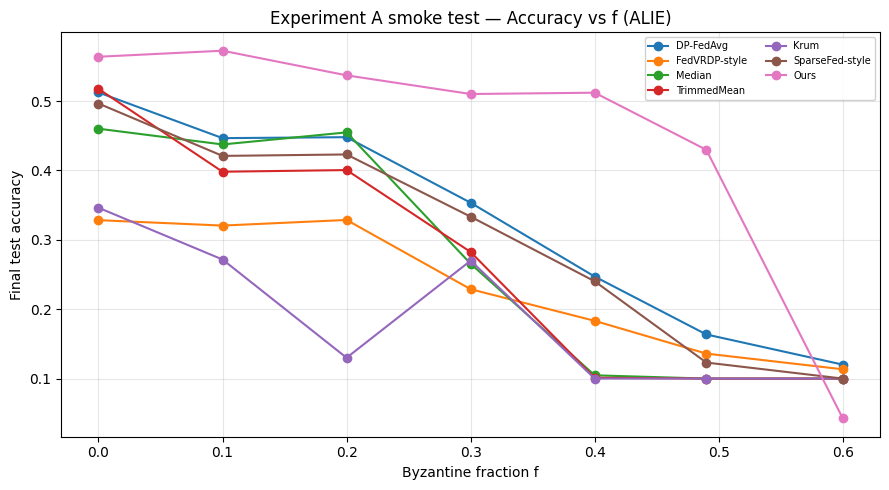

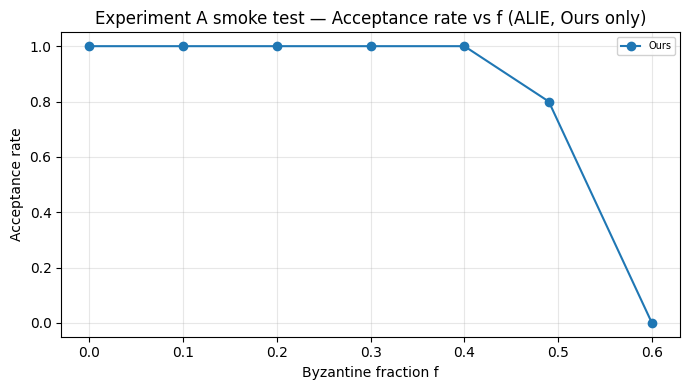


==================== Attack: SF ====================
Saved expA_smoke_sf.csv


,attack,method,f,acc,accept_rate
0,SF,DP-FedAvg,0.00,0.5124,NaN
1,SF,DP-FedAvg,0.10,0.2628,NaN
2,SF,DP-FedAvg,0.20,0.0302,NaN
3,SF,DP-FedAvg,0.30,0.0194,NaN
4,SF,DP-FedAvg,0.40,0.0161,NaN
5,SF,DP-FedAvg,0.49,0.0989,NaN
6,SF,DP-FedAvg,0.60,0.1000,NaN
7,SF,FedVRDP-style,0.00,0.3283,NaN
8,SF,FedVRDP-style,0.10,0.0998,NaN
9,SF,FedVRDP-style,0.20,0.0350,NaN


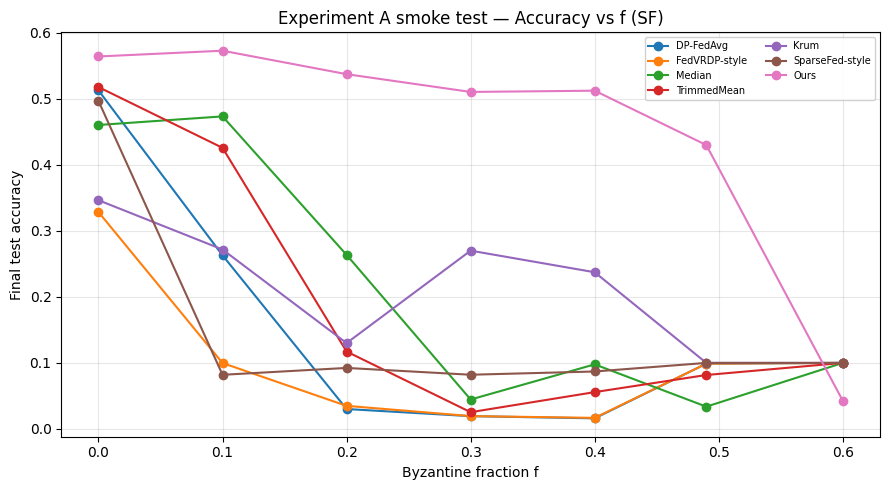

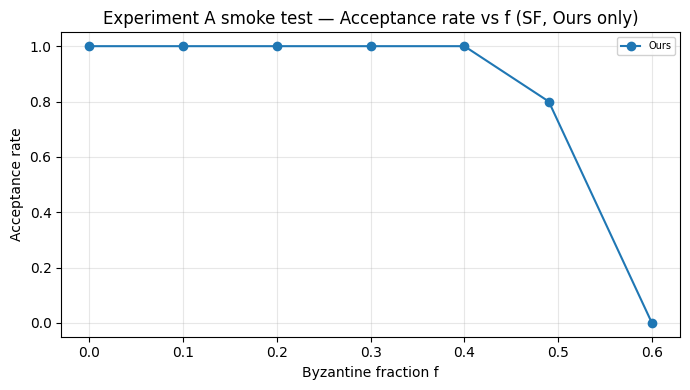


==================== Attack: MinMax ====================
Saved expA_smoke_minmax.csv


,attack,method,f,acc,accept_rate
0,MinMax,DP-FedAvg,0.00,0.5124,NaN
1,MinMax,DP-FedAvg,0.10,0.3775,NaN
2,MinMax,DP-FedAvg,0.20,0.2536,NaN
3,MinMax,DP-FedAvg,0.30,0.1646,NaN
4,MinMax,DP-FedAvg,0.40,0.0801,NaN
5,MinMax,DP-FedAvg,0.49,0.0499,NaN
6,MinMax,DP-FedAvg,0.60,0.0530,NaN
7,MinMax,FedVRDP-style,0.00,0.3283,NaN
8,MinMax,FedVRDP-style,0.10,0.2009,NaN
9,MinMax,FedVRDP-style,0.20,0.1053,NaN


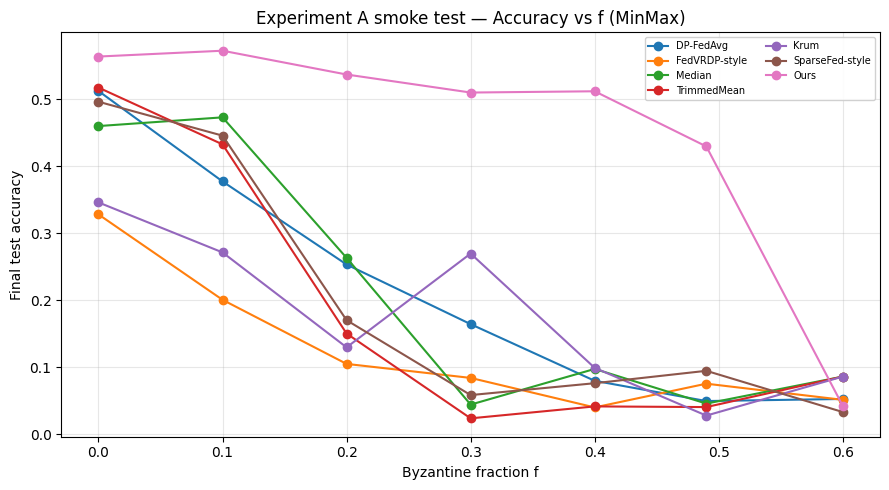

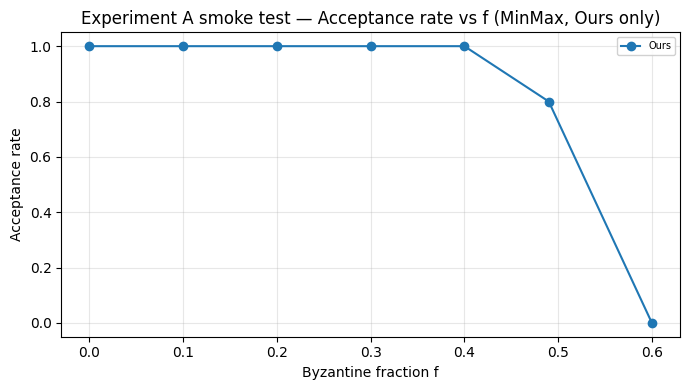


==================== Attack: MinSum ====================
Saved expA_smoke_minsum.csv


,attack,method,f,acc,accept_rate
0,MinSum,DP-FedAvg,0.00,0.5124,NaN
1,MinSum,DP-FedAvg,0.10,0.3893,NaN
2,MinSum,DP-FedAvg,0.20,0.3458,NaN
3,MinSum,DP-FedAvg,0.30,0.2211,NaN
4,MinSum,DP-FedAvg,0.40,0.1448,NaN
5,MinSum,DP-FedAvg,0.49,0.0990,NaN
6,MinSum,DP-FedAvg,0.60,0.0665,NaN
7,MinSum,FedVRDP-style,0.00,0.3283,NaN
8,MinSum,FedVRDP-style,0.10,0.2180,NaN
9,MinSum,FedVRDP-style,0.20,0.1111,NaN


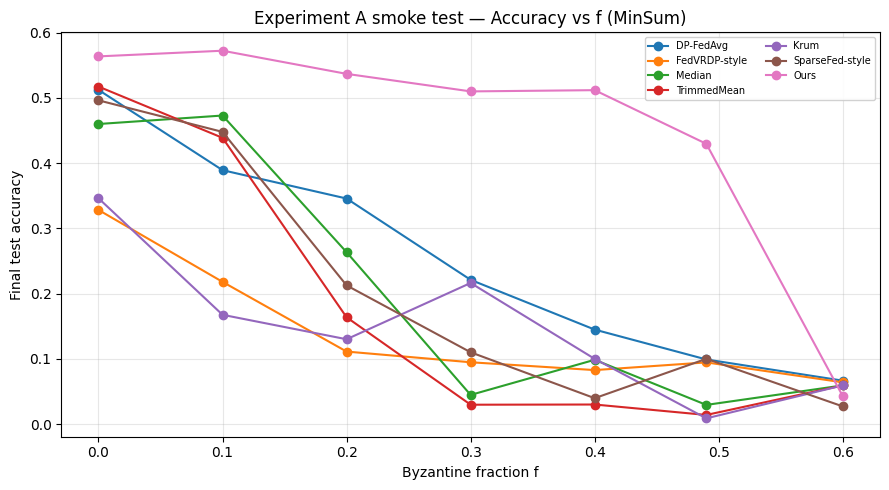

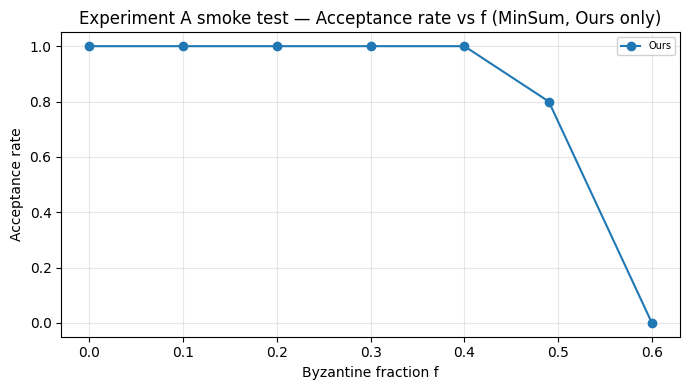


==================== Attack: LF ====================
Saved expA_smoke_lf.csv


,attack,method,f,acc,accept_rate
0,LF,DP-FedAvg,0.00,0.5124,NaN
1,LF,DP-FedAvg,0.10,0.4808,NaN
2,LF,DP-FedAvg,0.20,0.4467,NaN
3,LF,DP-FedAvg,0.30,0.3934,NaN
4,LF,DP-FedAvg,0.40,0.3626,NaN
5,LF,DP-FedAvg,0.49,0.3434,NaN
6,LF,DP-FedAvg,0.60,0.1984,NaN
7,LF,FedVRDP-style,0.00,0.3283,NaN
8,LF,FedVRDP-style,0.10,0.3165,NaN
9,LF,FedVRDP-style,0.20,0.3108,NaN


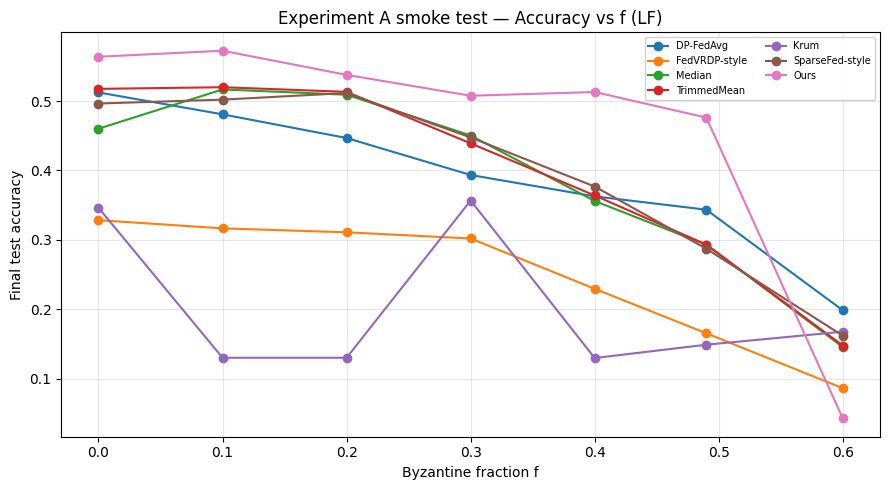

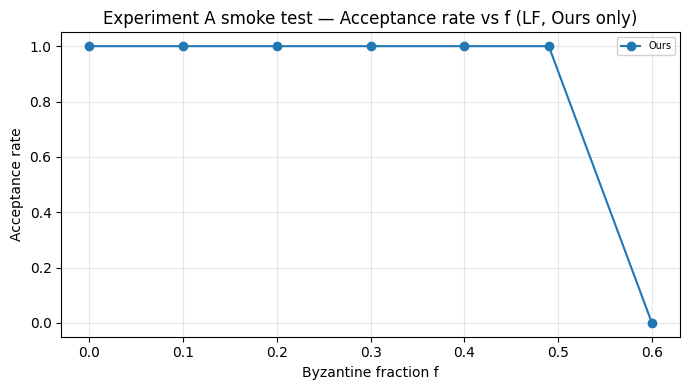


==================== Attack: FoE ====================
Saved expA_smoke_foe.csv


,attack,method,f,acc,accept_rate
0,FoE,DP-FedAvg,0.00,0.5124,NaN
1,FoE,DP-FedAvg,0.10,0.4235,NaN
2,FoE,DP-FedAvg,0.20,0.4183,NaN
3,FoE,DP-FedAvg,0.30,0.3755,NaN
4,FoE,DP-FedAvg,0.40,0.3193,NaN
5,FoE,DP-FedAvg,0.49,0.1654,NaN
6,FoE,DP-FedAvg,0.60,0.0791,NaN
7,FoE,FedVRDP-style,0.00,0.3283,NaN
8,FoE,FedVRDP-style,0.10,0.2820,NaN
9,FoE,FedVRDP-style,0.20,0.1982,NaN


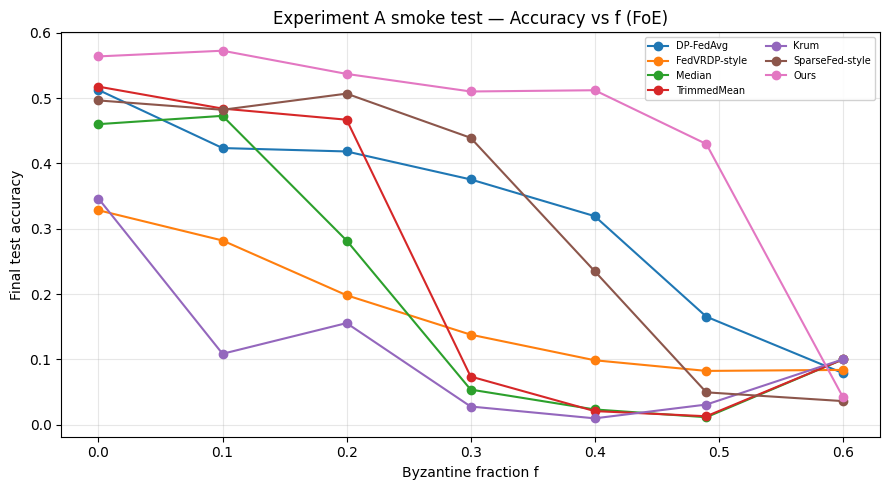

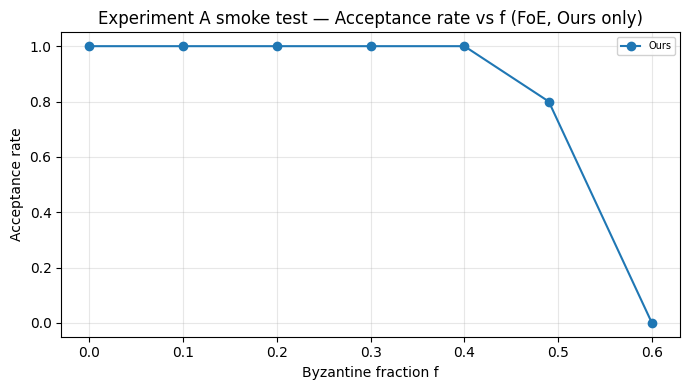


Saved expA_smoke_all_results.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg,0.00,0.5124,NaN
1,ALIE,DP-FedAvg,0.10,0.4465,NaN
2,ALIE,DP-FedAvg,0.20,0.4479,NaN
3,ALIE,DP-FedAvg,0.30,0.3534,NaN
4,ALIE,DP-FedAvg,0.40,0.2470,NaN
...,...,...,...,...,...
289,SF,AG-PTR,0.20,0.5370,1.0
290,SF,AG-PTR,0.30,0.5101,1.0
291,SF,AG-PTR,0.40,0.5120,1.0
292,SF,AG-PTR,0.49,0.4297,0.8


In [ ]:
# Cell 14 — Smoke test only: all attacks × all methods
# Methods:
#   AG-PTR, DP-FedAvg, FedVRDP-style, Median, TrimmedMean, Krum, SparseFed-style
# Attacks:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Output:
#   - one table per attack
#   - one accuracy chart per attack (all methods on one plot)
#   - one acceptance-rate chart per attack (AG-PTR only, shown as "Ours")

seed = 0
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

# Attack params
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1   # LF = cyclic label flip y -> (y + 1) % 10

# AG-PTR params
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2

# DP-FedAvg / FedVRDP-style params
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30

# SparseFed-style params
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

ATTACKS = [
    ("ALIE",   "alie"),
    ("SF",     "sf"),
    ("MinMax", "minmax"),
    ("MinSum", "minsum"),
    ("LF",     "lf"),
    ("FoE",    "foe"),
]

METHOD_ORDER = [
    "DP-FedAvg",
    "FedVRDP-style",
    "Median",
    "TrimmedMean",
    "Krum",
    "SparseFed-style",
    "AG-PTR",
]

LEGEND_LABELS = {
    "DP-FedAvg": "DP-FedAvg",
    "FedVRDP-style": "FedVRDP-style",
    "Median": "Median",
    "TrimmedMean": "TrimmedMean",
    "Krum": "Krum",
    "SparseFed-style": "SparseFed-style",
    "AG-PTR": "Ours",
}

q = CLIENTS_PER_ROUND / len(clients)

sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
eps_dp = epsilon_from_sigma_single(sigma_dp, q, ROUNDS, delta)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("sigma_dp:", sigma_dp, "achieved eps≈", eps_dp)
print("sigma_ag sel/rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)
print(f"seed={seed}, rounds={ROUNDS}, local_epochs={LOCAL_EPOCHS}, batch_size={BATCH_SIZE}")
print(f"AG-PTR: rho={RHO}, tau={TAU}, R_pub_avg={R_PUB_AVG}, pub_batch={PUB_BATCH}, pub_scale={PUB_SCALE}")
print(f"ALIE: z={ALIE_Z}, dir={ALIE_DIR}")
print(f"SF scale={SF_SCALE}, FoE scale={FOE_SCALE}, LF shift={LABEL_FLIP_SHIFT}")
print(f"FedVRDP-style: clip_C={CLIP_C_VR}, k_frac={K_FRAC_VR}")
print(f"SparseFed-style: clip_C={CLIP_C_SPARSE}, k_frac={K_FRAC_SPARSE}")

all_rows = []

for attack_name, attack_key in ATTACKS:
    print(f"\n==================== Attack: {attack_name} ====================")
    attack_rows = []

    for f in f_list:
        acc_dp, _ = train_dp_fedavg_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_DP,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_vr, _ = train_fedvrdp_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC_VR,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_med, _ = train_median_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_tmean, _ = train_trimmedmean_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            trim_k=None,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_krum, _ = train_krum_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_sparse, _ = train_sparsefed_style_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_ag, ar_ag = train_ag_ptr(
            seed, eps_total, f,
            sigma_sel, sigma_rel, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            rho=RHO, tau=TAU,
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            allow_zero=False,
            show_progress=False
        )

        attack_rows.extend([
            {"attack": attack_name, "method": "DP-FedAvg",       "f": f, "acc": acc_dp,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "FedVRDP-style",   "f": f, "acc": acc_vr,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "Median",          "f": f, "acc": acc_med,    "accept_rate": np.nan},
            {"attack": attack_name, "method": "TrimmedMean",     "f": f, "acc": acc_tmean,  "accept_rate": np.nan},
            {"attack": attack_name, "method": "Krum",            "f": f, "acc": acc_krum,   "accept_rate": np.nan},
            {"attack": attack_name, "method": "SparseFed-style", "f": f, "acc": acc_sparse, "accept_rate": np.nan},
            {"attack": attack_name, "method": "AG-PTR",          "f": f, "acc": acc_ag,     "accept_rate": ar_ag},
        ])

    df_attack = pd.DataFrame(attack_rows)
    df_attack["method"] = pd.Categorical(df_attack["method"], categories=METHOD_ORDER, ordered=True)
    df_attack = df_attack.sort_values(["method", "f"]).reset_index(drop=True)

    df_attack.to_csv(f"expA_smoke_{attack_key}.csv", index=False)
    print(f"Saved expA_smoke_{attack_key}.csv")
    display(df_attack)

    # Accuracy chart: all methods, legend inside the plot
    fig, ax = plt.subplots(figsize=(9, 5))
    for method in METHOD_ORDER:
        sub = df_attack[df_attack["method"] == method]
        ax.plot(sub["f"], sub["acc"], marker="o", label=LEGEND_LABELS[method])
    ax.set_xlabel("Byzantine fraction f")
    ax.set_ylabel("Final test accuracy")
    ax.set_title(f"Experiment A smoke test — Accuracy vs f ({attack_name})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9, ncol=2)
    fig.tight_layout()
    plt.show()

    # Acceptance-rate chart: AG-PTR only, legend inside the plot
    fig, ax = plt.subplots(figsize=(7, 4))
    sub = df_attack[df_attack["method"] == "AG-PTR"]
    ax.plot(sub["f"], sub["accept_rate"], marker="o", label="Ours")
    ax.set_xlabel("Byzantine fraction f")
    ax.set_ylabel("Acceptance rate")
    ax.set_title(f"Experiment A smoke test — Acceptance rate vs f ({attack_name}, Ours only)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9)
    fig.tight_layout()
    plt.show()

    all_rows.extend(attack_rows)

df_smoke_all = pd.DataFrame(all_rows)
df_smoke_all["method"] = pd.Categorical(df_smoke_all["method"], categories=METHOD_ORDER, ordered=True)
df_smoke_all = df_smoke_all.sort_values(["attack", "method", "f"]).reset_index(drop=True)

df_smoke_all.to_csv("expA_smoke_all_results.csv", index=False)
print("\nSaved expA_smoke_all_results.csv")
display(df_smoke_all)

sigma_dp: 0.9723217465539842 achieved eps≈ 1.9999999999999973
sigma_ag sel/rel: 1.965902445173369 0.9829512225866845 achieved eps≈ 1.999999999999998
seed=0, rounds=180, local_epochs=1, batch_size=10
AG-PTR: rho=0.4, tau=50, R_pub_avg=16, pub_batch=40, pub_scale=0.12
ALIE: z=2.0, dir=-1.0
SF scale=5.0, FoE scale=1.0, LF shift=1
FedVRDP-style: clip_C=0.5, k_frac=0.3
SparseFed-style: clip_C=1.0, k_frac=0.3

==================== Attack: ALIE ====================
Saved expA_alie.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg,0.00,0.7238,NaN
1,ALIE,DP-FedAvg,0.10,0.6956,NaN
2,ALIE,DP-FedAvg,0.20,0.6337,NaN
3,ALIE,DP-FedAvg,0.30,0.5420,NaN
4,ALIE,DP-FedAvg,0.40,0.3022,NaN
5,ALIE,DP-FedAvg,0.49,0.2028,NaN
6,ALIE,DP-FedAvg,0.60,0.1219,NaN
7,ALIE,FedVRDP-style,0.00,0.7628,NaN
8,ALIE,FedVRDP-style,0.10,0.7417,NaN
9,ALIE,FedVRDP-style,0.20,0.7046,NaN


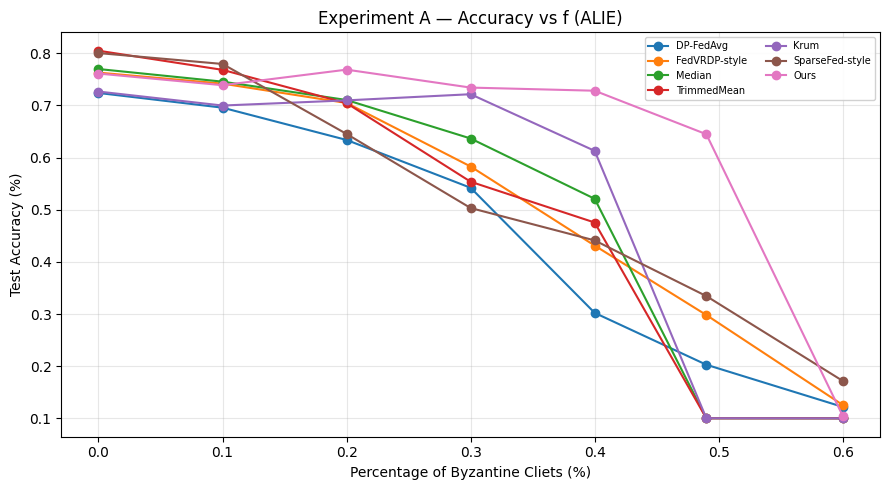

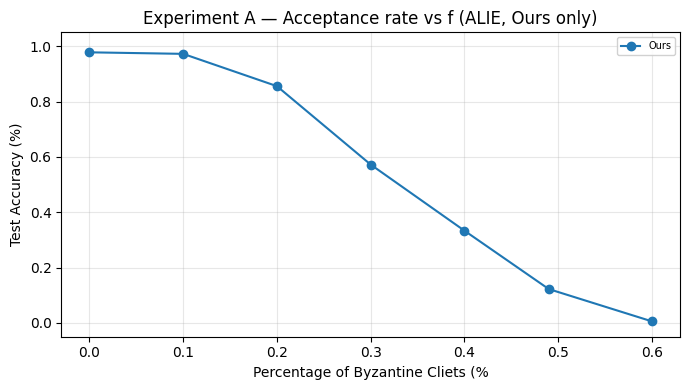


==================== Attack: SF ====================
Saved expA_sf.csv


,attack,method,f,acc,accept_rate
0,SF,DP-FedAvg,0.00,0.7238,NaN
1,SF,DP-FedAvg,0.10,0.5799,NaN
2,SF,DP-FedAvg,0.20,0.5161,NaN
3,SF,DP-FedAvg,0.30,0.3064,NaN
4,SF,DP-FedAvg,0.40,0.2387,NaN
5,SF,DP-FedAvg,0.49,0.1000,NaN
6,SF,DP-FedAvg,0.60,0.1000,NaN
7,SF,FedVRDP-style,0.00,0.7628,NaN
8,SF,FedVRDP-style,0.10,0.4032,NaN
9,SF,FedVRDP-style,0.20,0.1780,NaN


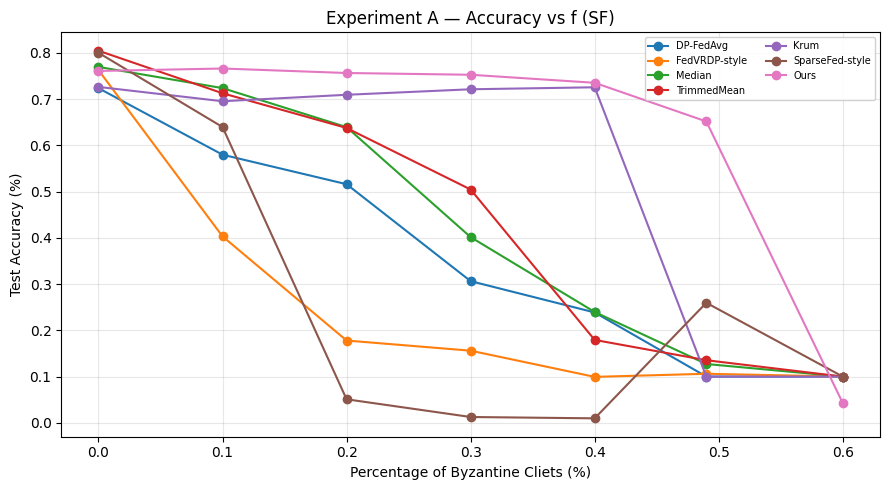

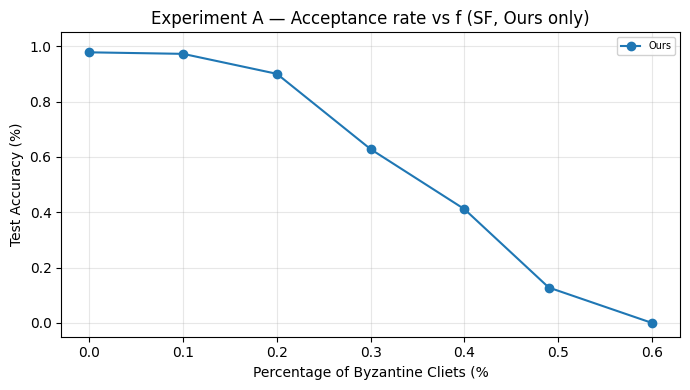


==================== Attack: MinMax ====================
Saved expA_minmax.csv


,attack,method,f,acc,accept_rate
0,MinMax,DP-FedAvg,0.00,0.7238,NaN
1,MinMax,DP-FedAvg,0.10,0.6685,NaN
2,MinMax,DP-FedAvg,0.20,0.5952,NaN
3,MinMax,DP-FedAvg,0.30,0.3760,NaN
4,MinMax,DP-FedAvg,0.40,0.3298,NaN
5,MinMax,DP-FedAvg,0.49,0.2553,NaN
6,MinMax,DP-FedAvg,0.60,0.1037,NaN
7,MinMax,FedVRDP-style,0.00,0.7628,NaN
8,MinMax,FedVRDP-style,0.10,0.7047,NaN
9,MinMax,FedVRDP-style,0.20,0.6550,NaN


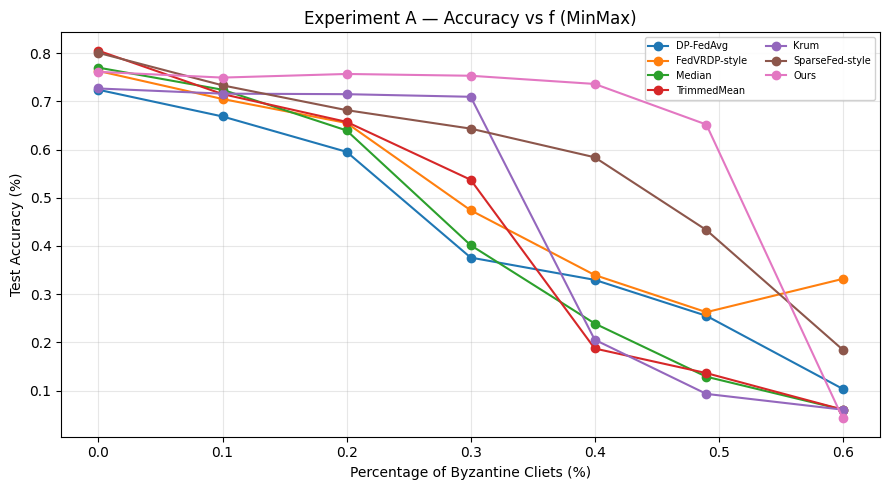

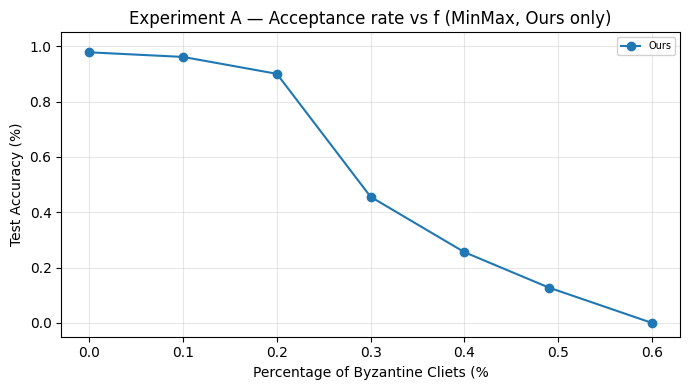


==================== Attack: MinSum ====================
Saved expA_minsum.csv


,attack,method,f,acc,accept_rate
0,MinSum,DP-FedAvg,0.00,0.7238,NaN
1,MinSum,DP-FedAvg,0.10,0.6878,NaN
2,MinSum,DP-FedAvg,0.20,0.5607,NaN
3,MinSum,DP-FedAvg,0.30,0.4645,NaN
4,MinSum,DP-FedAvg,0.40,0.3280,NaN
5,MinSum,DP-FedAvg,0.49,0.3040,NaN
6,MinSum,DP-FedAvg,0.60,0.0953,NaN
7,MinSum,FedVRDP-style,0.00,0.7628,NaN
8,MinSum,FedVRDP-style,0.10,0.7055,NaN
9,MinSum,FedVRDP-style,0.20,0.6683,NaN


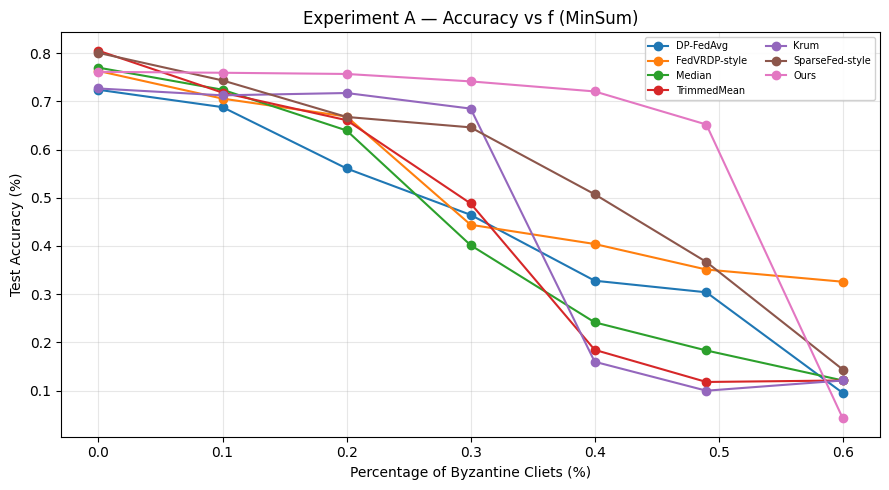

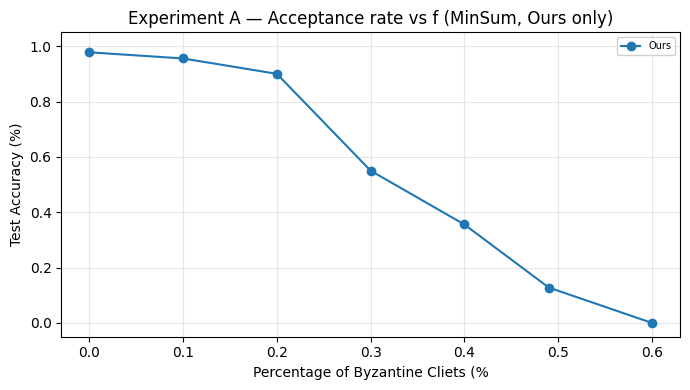


==================== Attack: LF ====================
Saved expA_lf.csv


,attack,method,f,acc,accept_rate
0,LF,DP-FedAvg,0.00,0.7238,NaN
1,LF,DP-FedAvg,0.10,0.6852,NaN
2,LF,DP-FedAvg,0.20,0.6456,NaN
3,LF,DP-FedAvg,0.30,0.5733,NaN
4,LF,DP-FedAvg,0.40,0.4891,NaN
5,LF,DP-FedAvg,0.49,0.4049,NaN
6,LF,DP-FedAvg,0.60,0.2720,NaN
7,LF,FedVRDP-style,0.00,0.7628,NaN
8,LF,FedVRDP-style,0.10,0.7417,NaN
9,LF,FedVRDP-style,0.20,0.7219,NaN


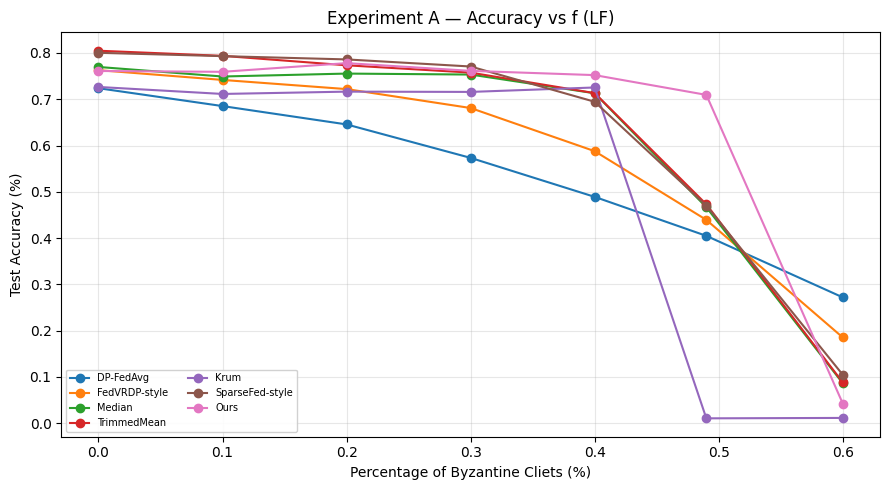

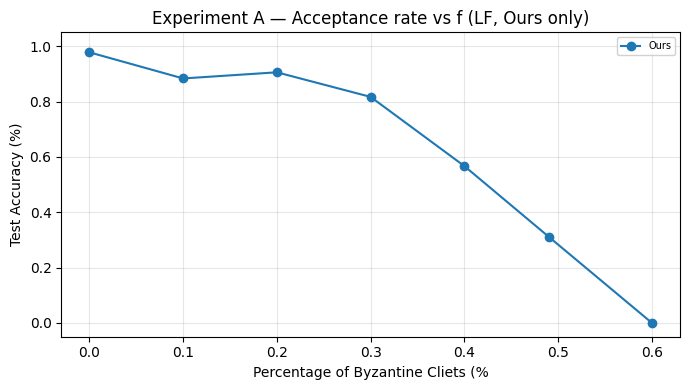


==================== Attack: FoE ====================
Saved expA_foe.csv


,attack,method,f,acc,accept_rate
0,FoE,DP-FedAvg,0.00,0.7238,NaN
1,FoE,DP-FedAvg,0.10,0.7202,NaN
2,FoE,DP-FedAvg,0.20,0.6980,NaN
3,FoE,DP-FedAvg,0.30,0.6725,NaN
4,FoE,DP-FedAvg,0.40,0.5581,NaN
5,FoE,DP-FedAvg,0.49,0.1000,NaN
6,FoE,DP-FedAvg,0.60,0.1000,NaN
7,FoE,FedVRDP-style,0.00,0.7628,NaN
8,FoE,FedVRDP-style,0.10,0.7449,NaN
9,FoE,FedVRDP-style,0.20,0.7144,NaN


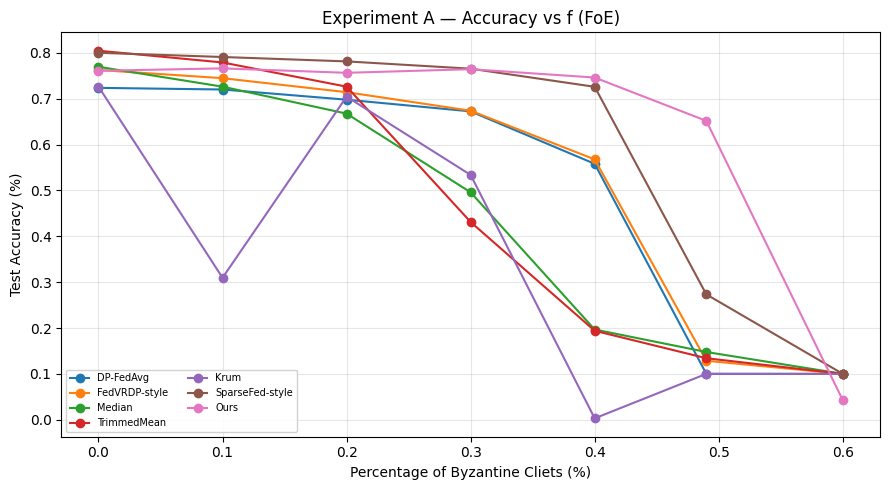

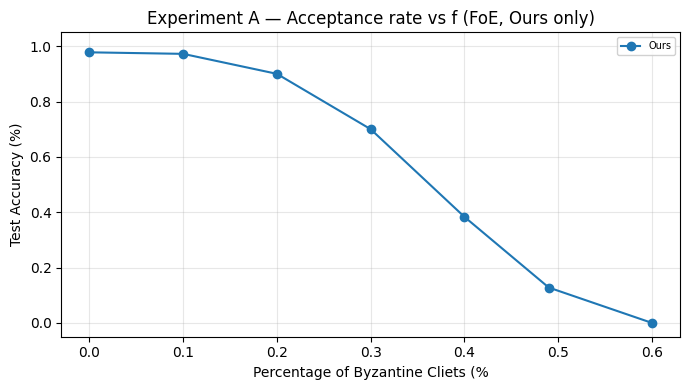

In [ ]:
# Cell 15 — Long Run

seed = 0
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 180
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

# Attack params
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1   # LF = cyclic label flip y -> (y + 1) % 10

# AG-PTR params
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2

# DP-FedAvg / FedVRDP-style params
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30

# SparseFed-style params
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

ATTACKS = [
    ("ALIE",   "alie"),
    ("SF",     "sf"),
    ("MinMax", "minmax"),
    ("MinSum", "minsum"),
    ("LF",     "lf"),
    ("FoE",    "foe"),
]

METHOD_ORDER = [
    "DP-FedAvg",
    "FedVRDP-style",
    "Median",
    "TrimmedMean",
    "Krum",
    "SparseFed-style",
    "AG-PTR",
]

LEGEND_LABELS = {
    "DP-FedAvg": "DP-FedAvg",
    "FedVRDP-style": "FedVRDP-style",
    "Median": "Median",
    "TrimmedMean": "TrimmedMean",
    "Krum": "Krum",
    "SparseFed-style": "SparseFed-style",
    "AG-PTR": "Ours",
}

q = CLIENTS_PER_ROUND / len(clients)

sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
eps_dp = epsilon_from_sigma_single(sigma_dp, q, ROUNDS, delta)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("sigma_dp:", sigma_dp, "achieved eps≈", eps_dp)
print("sigma_ag sel/rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)
print(f"seed={seed}, rounds={ROUNDS}, local_epochs={LOCAL_EPOCHS}, batch_size={BATCH_SIZE}")
print(f"AG-PTR: rho={RHO}, tau={TAU}, R_pub_avg={R_PUB_AVG}, pub_batch={PUB_BATCH}, pub_scale={PUB_SCALE}")
print(f"ALIE: z={ALIE_Z}, dir={ALIE_DIR}")
print(f"SF scale={SF_SCALE}, FoE scale={FOE_SCALE}, LF shift={LABEL_FLIP_SHIFT}")
print(f"FedVRDP-style: clip_C={CLIP_C_VR}, k_frac={K_FRAC_VR}")
print(f"SparseFed-style: clip_C={CLIP_C_SPARSE}, k_frac={K_FRAC_SPARSE}")

all_rows = []

for attack_name, attack_key in ATTACKS:
    print(f"\n==================== Attack: {attack_name} ====================")
    attack_rows = []

    for f in f_list:
        acc_dp, _ = train_dp_fedavg_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_DP,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_vr, _ = train_fedvrdp_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC_VR,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_med, _ = train_median_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_tmean, _ = train_trimmedmean_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            trim_k=None,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_krum, _ = train_krum_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_sparse, _ = train_sparsefed_style_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_ag, ar_ag = train_ag_ptr(
            seed, eps_total, f,
            sigma_sel, sigma_rel, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            rho=RHO, tau=TAU,
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            allow_zero=False,
            show_progress=False
        )

        attack_rows.extend([
            {"attack": attack_name, "method": "DP-FedAvg",       "f": f, "acc": acc_dp,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "FedVRDP-style",   "f": f, "acc": acc_vr,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "Median",          "f": f, "acc": acc_med,    "accept_rate": np.nan},
            {"attack": attack_name, "method": "TrimmedMean",     "f": f, "acc": acc_tmean,  "accept_rate": np.nan},
            {"attack": attack_name, "method": "Krum",            "f": f, "acc": acc_krum,   "accept_rate": np.nan},
            {"attack": attack_name, "method": "SparseFed-style", "f": f, "acc": acc_sparse, "accept_rate": np.nan},
            {"attack": attack_name, "method": "AG-PTR",          "f": f, "acc": acc_ag,     "accept_rate": ar_ag},
        ])

    df_attack = pd.DataFrame(attack_rows)
    df_attack["method"] = pd.Categorical(df_attack["method"], categories=METHOD_ORDER, ordered=True)
    df_attack = df_attack.sort_values(["method", "f"]).reset_index(drop=True)

    df_attack.to_csv(f"expA_{attack_key}.csv", index=False)
    print(f"Saved expA_{attack_key}.csv")
    display(df_attack)

    # Accuracy chart: all methods, legend inside the plot
    fig, ax = plt.subplots(figsize=(9, 5))
    for method in METHOD_ORDER:
        sub = df_attack[df_attack["method"] == method]
        ax.plot(sub["f"], sub["acc"], marker="o", label=LEGEND_LABELS[method])
    ax.set_xlabel("Percentage of Byzantine Cliets (%)")
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title(f"Experiment A — Accuracy vs f ({attack_name})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9, ncol=2)
    fig.tight_layout()
    plt.show()

    # Acceptance-rate chart: AG-PTR only, legend inside the plot
    fig, ax = plt.subplots(figsize=(7, 4))
    sub = df_attack[df_attack["method"] == "AG-PTR"]
    ax.plot(sub["f"], sub["accept_rate"], marker="o", label="Ours")
    ax.set_xlabel("Percentage of Byzantine Cliets (%")
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title(f"Experiment A — Acceptance rate vs f ({attack_name}, Ours only)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9)
    fig.tight_layout()
    plt.show()

    all_rows.extend(attack_rows)

df_smoke_all = pd.DataFrame(all_rows)
df_smoke_all["method"] = pd.Categorical(df_smoke_all["method"], categories=METHOD_ORDER, ordered=True)
df_smoke_all = df_smoke_all.sort_values(["attack", "method", "f"]).reset_index(drop=True)

df_smoke_all.to_csv("expA_all_results.csv", index=False)

In [ ]:
# Cell 16 — Robust driver DEFINITIONS (added Sep 2026). 
#  * Every finished run is appended IMMEDIATELY to a CSV in MyDrive/agptr_runs, keyed by
#    (attack, method, f, seed, sigma_mode).  Re-running a job resumes: finished runs are skipped,
#    and a job never deletes another job's rows.
#  * Each job below is its own cell, so its log / summary / plots stay saved in this notebook.
#  * SIGMA_MODE "nominal"   = the paper's executed multipliers (per-phase accountant)
#               "certified" = composed accountant: sigma_rel = (sqrt5/2)*sigma_dp for eps=2 (1.0871 on F-MNIST)
import os, time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRESETS = {
    "smoke":     dict(RUN_TAG="smoke", SEEDS=[0],    SUBSET_ATTACKS=["alie"],           SUBSET_FRACS=[0.0],        SUBSET_METHODS=["AG-PTR", "DP-FedAvg"],                SIGMA_MODE="nominal",   ROUNDS=3,   MAX_RUNS_THIS_SESSION=2),
    "seeds":     dict(RUN_TAG="expA",  SEEDS=[1, 2], SUBSET_ATTACKS=["alie", "minmax"], SUBSET_FRACS=[0.00, 0.40], SUBSET_METHODS=["AG-PTR", "DP-FedAvg", "TrimmedMean"], SIGMA_MODE="nominal",   ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "certified": dict(RUN_TAG="expA",  SEEDS=[0],    SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None,         SUBSET_METHODS=["AG-PTR"],                             SIGMA_MODE="certified", ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "inball":    dict(RUN_TAG="expA",  SEEDS=[0],    SUBSET_ATTACKS=["inball"],         SUBSET_FRACS=None,         SUBSET_METHODS=["AG-PTR"],                             SIGMA_MODE="nominal",   ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "custom":    dict(RUN_TAG="expA",  SEEDS=[1, 2], SUBSET_ATTACKS=None,               SUBSET_FRACS=None,         SUBSET_METHODS=None,                                   SIGMA_MODE="nominal",   ROUNDS=180, MAX_RUNS_THIS_SESSION=12),
}
RESULTS_DIR = "/content/drive/MyDrive/agptr_runs"
INBALL_SCALE = 1.0                # in-ball attack radius as a fraction of rho

try:
    from google.colab import drive as _gdrive
    if not os.path.isdir("/content/drive/MyDrive"):
        _gdrive.mount("/content/drive")
except Exception as _e:
    print("Google Drive not available (%s); saving locally." % (_e,))
    RESULTS_DIR = os.path.abspath("./agptr_runs")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- fixed experiment settings (identical to the original full-run cell; ROUNDS comes from the job) ----
eps_total = 2.0
delta = 1e-5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10
LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

ATTACKS_ALL = [("ALIE","alie"), ("SF","sf"), ("MinMax","minmax"), ("MinSum","minsum"), ("LF","lf"), ("FoE","foe"), ("InBall","inball")]
METHODS_ALL = ["DP-FedAvg", "FedVRDP-style", "Median", "TrimmedMean", "Krum", "SparseFed-style", "AG-PTR"]
FRACS_ALL = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]
q = CLIENTS_PER_ROUND / len(clients)
sigma_dp = find_sigma_for_target_eps_single(eps_total, q, 180, delta)   # baselines: single release per round, T=180

def _key(attack_key, method, f, seed, sigma_mode):
    return (str(attack_key), str(method), "%.2f" % float(f), int(seed), str(sigma_mode))

def load_done(csv_path):
    if not os.path.exists(csv_path):
        return set()
    df = pd.read_csv(csv_path)
    if "status" in df.columns:
        df = df[df["status"] == "ok"]
    return set(_key(r.attack_key, r.method, r.f, r.seed, r.sigma_mode) for r in df.itertuples())

def append_row(csv_path, row):
    header = not os.path.exists(csv_path)
    pd.DataFrame([row]).to_csv(csv_path, mode="a", header=header, index=False)
    try:
        with open(csv_path, "a") as fh:
            fh.flush(); os.fsync(fh.fileno())
    except Exception:
        pass

def _sigmas(sigma_mode, rounds):
    sel_factor = 2.0
    if isinstance(sigma_mode, (int, float)):
        sr, tag = float(sigma_mode), "rel=%.4f" % float(sigma_mode)
    elif str(sigma_mode).lower() == "certified":
        sr, tag = find_sigma_rel_certified_two(eps_total, q, rounds, delta, sel_factor=sel_factor), "certified"
    else:
        sr, tag = find_sigma_rel_for_target_eps_two(eps_total, q, rounds, delta, sel_factor=sel_factor), "nominal"
    ss = sel_factor * sr
    return ss, sr, tag, epsilon_from_sigma_two(ss, sr, q, rounds, delta), epsilon_certified_two(ss, sr, q, rounds, delta)

CFG = {}   # filled by run_job(); read by run_method()

# ---- method dispatch (same arguments as the original full-run cell) ----
def run_method(method, seed, f, attack_key):
    common = dict(delta=delta, rounds=CFG["ROUNDS"], local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                  lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM, attack_type=attack_key,
                  alie_direction=ALIE_DIR, alie_z=ALIE_Z, sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
                  label_flip_shift=LABEL_FLIP_SHIFT, show_progress=False)
    if method == "DP-FedAvg":
        return train_dp_fedavg_robust(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_DP, **common)
    if method == "FedVRDP-style":
        return train_fedvrdp_robust(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **common)
    if method == "Median":
        return train_median_robust(seed, eps_total, f, **common)
    if method == "TrimmedMean":
        return train_trimmedmean_robust(seed, eps_total, f, trim_k=None, **common)
    if method == "Krum":
        return train_krum_robust(seed, eps_total, f, **common)
    if method == "SparseFed-style":
        return train_sparsefed_style_robust(seed, eps_total, f, clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE, **common)
    if method == "AG-PTR":
        return train_ag_ptr(seed, eps_total, f, CFG["sigma_sel"], CFG["sigma_rel"], rho=RHO, tau=TAU,
                            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                            allow_zero=False, inball_scale=INBALL_SCALE, **common)
    raise ValueError("unknown method %s" % method)

def run_job(job):
    P = PRESETS[job]
    rounds = P["ROUNDS"]
    ss, sr, mode_tag, eps_nom, eps_cert = _sigmas(P["SIGMA_MODE"], rounds)
    CFG.update(dict(RUN_TAG=P["RUN_TAG"], ROUNDS=rounds, sigma_sel=ss, sigma_rel=sr, sigma_mode=mode_tag))
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    print("JOB = %s | results file: %s" % (job, csv_path))
    print("q = %.6f | sigma_dp = %.4f | AG-PTR sigma mode = %s: sigma_sel = %.4f, sigma_rel = %.4f | eps nominal(per-phase) = %.3f | eps CERTIFIED(composed) = %.3f"
          % (q, sigma_dp, mode_tag, ss, sr, eps_nom, eps_cert))
    attacks = [(n, k) for (n, k) in ATTACKS_ALL if (P["SUBSET_ATTACKS"] is None or k in P["SUBSET_ATTACKS"])]
    fracs   = FRACS_ALL if P["SUBSET_FRACS"] is None else list(P["SUBSET_FRACS"])
    methods = METHODS_ALL if P["SUBSET_METHODS"] is None else list(P["SUBSET_METHODS"])
    unknown = [m for m in methods if m not in METHODS_ALL]
    if unknown:
        raise ValueError("Unknown method(s): %s" % unknown)
    done = load_done(csv_path)
    todo = [(seed, a_name, a_key, f, m) for seed in P["SEEDS"] for (a_name, a_key) in attacks for f in fracs for m in methods
            if not (a_key == "inball" and m != "AG-PTR") and _key(a_key, m, f, seed, mode_tag) not in done]
    print("%d runs already done, %d to do (this cell stops after %s runs; re-run it to continue)" % (len(done), len(todo), P["MAX_RUNS_THIS_SESSION"]))
    n_done_now, t_start = 0, time.time()
    for (seed, a_name, a_key, f, m) in todo:
        if P["MAX_RUNS_THIS_SESSION"] is not None and n_done_now >= P["MAX_RUNS_THIS_SESSION"]:
            print("session limit reached; re-run this cell to continue."); break
        t0 = time.time(); status, err = "ok", ""
        try:
            acc, ar = run_method(m, seed, f, a_key)
        except Exception as e:
            acc, ar, status, err = np.nan, np.nan, "error", repr(e)[:300]
        append_row(csv_path, {"exp": P["RUN_TAG"], "attack": a_name, "attack_key": a_key, "method": m, "f": float(f), "seed": int(seed),
                              "sigma_mode": mode_tag, "sigma_dp": sigma_dp, "sigma_sel": ss, "sigma_rel": sr,
                              "eps_nominal": eps_nom, "eps_certified": eps_cert, "rounds": rounds,
                              "acc": acc, "accept_rate": ar, "wall_sec": round(time.time() - t0, 1),
                              "status": status, "error": err, "source": "run",
                              "timestamp": datetime.datetime.now().isoformat(timespec="seconds")})
        n_done_now += 1
        try:
            cleanup_cuda()
        except Exception:
            pass
        eta = (time.time() - t_start) / n_done_now * (len(todo) - n_done_now)
        print("[%d/%d] seed=%d %-7s f=%.2f %-24s acc=%s accept=%s (%s, %.0fs, ETA %.0f min)"
              % (n_done_now, len(todo), seed, a_name, f, m, "n/a" if acc != acc else "%.4f" % acc,
                 "n/a" if ar != ar else "%.3f" % ar, status, time.time() - t0, eta / 60))
    print("done for now:", csv_path)
    return csv_path

def import_legacy(job, legacy_name="expA_all_results.csv"):
    # adds the paper's original seed-0 rows (nominal sigma) to the job's CSV so the aggregate includes them
    P = PRESETS[job]
    if job == "smoke":
        print("smoke job: legacy import skipped"); return
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    cands = [os.path.join(RESULTS_DIR, legacy_name), legacy_name, os.path.join("/content", legacy_name)]
    src = next((p for p in cands if os.path.exists(p)), None)
    if src is None:
        print("legacy file", legacy_name, "not found in", cands, "- skipped"); return
    leg = pd.read_csv(src); name2key = {n: k for (n, k) in ATTACKS_ALL}; done = load_done(csv_path); added = 0
    for r in leg.itertuples():
        a_key = name2key.get(str(r.attack), str(r.attack).lower())
        if _key(a_key, r.method, r.f, 0, "nominal") in done:
            continue
        append_row(csv_path, {"exp": P["RUN_TAG"], "attack": r.attack, "attack_key": a_key, "method": r.method, "f": float(r.f), "seed": 0,
                              "sigma_mode": "nominal", "sigma_dp": np.nan, "sigma_sel": np.nan, "sigma_rel": np.nan,
                              "eps_nominal": np.nan, "eps_certified": np.nan, "rounds": 180, "acc": r.acc, "accept_rate": r.accept_rate,
                              "wall_sec": np.nan, "status": "ok", "error": "", "source": "legacy",
                              "timestamp": datetime.datetime.now().isoformat(timespec="seconds")})
        added += 1
    print("imported %d legacy (seed-0) rows from %s" % (added, src))

def aggregate(job):
    # mean +/- std over seeds per (sigma_mode, attack, method, f), summary CSV, error-bar plots
    P = PRESETS[job]
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    df = pd.read_csv(csv_path); df = df[df["status"] == "ok"].copy()
    summary = (df.groupby(["sigma_mode", "attack_key", "attack", "method", "f"])
                 .agg(acc_mean=("acc", "mean"), acc_std=("acc", "std"), n_seeds=("acc", "count"),
                      accept_mean=("accept_rate", "mean"), accept_std=("accept_rate", "std"))
                 .reset_index().sort_values(["sigma_mode", "attack_key", "method", "f"]))
    summary["acc_std"] = summary["acc_std"].fillna(0.0)
    out = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_seed_summary.csv"); summary.to_csv(out, index=False)
    print("saved", out); display(summary)
    for (mode, a_key), sub in summary.groupby(["sigma_mode", "attack_key"]):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for m, ss_ in sub.groupby("method"):
            ss_ = ss_.sort_values("f")
            ax.errorbar(ss_["f"], ss_["acc_mean"], yerr=ss_["acc_std"], marker="o", capsize=3, label="%s (n=%d)" % (m, int(ss_["n_seeds"].max())))
        ax.set_xlabel("Byzantine fraction"); ax.set_ylabel("Test accuracy (mean +/- std over seeds)")
        ax.set_title("%s — %s — sigma mode: %s" % (P["RUN_TAG"], a_key.upper(), mode)); ax.grid(True, alpha=0.3); ax.legend(loc="best", fontsize=7, ncol=2)
        fig.tight_layout(); plt.show()
print("driver definitions loaded; now run the job cells below")


driver definitions loaded; now run the job cells below


JOB = smoke | results file: /content/drive/MyDrive/agptr_runs/smoke_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR sigma mode = nominal: sigma_sel = 1.5841, sigma_rel = 0.7920 | eps nominal(per-phase) = 2.000 | eps CERTIFIED(composed) = 2.585
0 runs already done, 2 to do (this cell stops after 2 runs; re-run it to continue)
[1/2] seed=0 ALIE    f=0.00 AG-PTR                   acc=0.4428 accept=1.000 (ok, 2s, ETA 0 min)
[2/2] seed=0 ALIE    f=0.00 DP-FedAvg                acc=0.3154 accept=1.000 (ok, 1s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/smoke_results.csv
smoke job: legacy import skipped
saved /content/drive/MyDrive/agptr_runs/smoke_seed_summary.csv


,sigma_mode,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,nominal,alie,ALIE,AG-PTR,0.0,0.4428,0.0,1,1.0,NaN
1,nominal,alie,ALIE,DP-FedAvg,0.0,0.3154,0.0,1,1.0,NaN


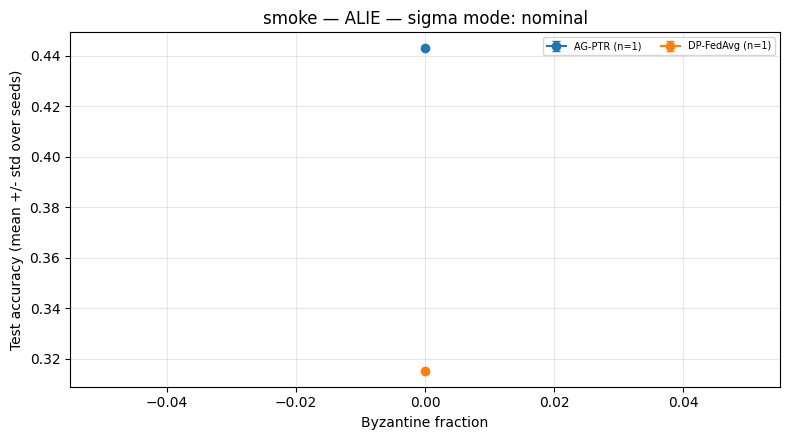

In [ ]:
# Cell 16a — JOB: smoke  (2 short runs, ~10 min: checks the notebook works)
run_job("smoke")
import_legacy("smoke")
aggregate("smoke")


JOB = seeds | results file: /content/drive/MyDrive/agptr_runs/expA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR sigma mode = nominal: sigma_sel = 1.9659, sigma_rel = 0.9830 | eps nominal(per-phase) = 2.000 | eps CERTIFIED(composed) = 2.591
0 runs already done, 24 to do (this cell stops after None runs; re-run it to continue)
[1/24] seed=1 ALIE    f=0.00 AG-PTR                   acc=0.7628 accept=0.950 (ok, 89s, ETA 34 min)
[2/24] seed=1 ALIE    f=0.00 DP-FedAvg                acc=0.7268 accept=1.000 (ok, 62s, ETA 28 min)
[3/24] seed=1 ALIE    f=0.00 TrimmedMean              acc=0.7854 accept=1.000 (ok, 82s, ETA 27 min)
[4/24] seed=1 ALIE    f=0.40 AG-PTR                   acc=0.7001 accept=0.383 (ok, 64s, ETA 25 min)
[5/24] seed=1 ALIE    f=0.40 DP-FedAvg                acc=0.3883 accept=1.000 (ok, 42s, ETA 21 min)
[6/24] seed=1 ALIE    f=0.40 TrimmedMean              acc=0.2004 accept=1.000 (ok, 122s, ETA 23 min)
[7/24] seed=1 MinMax  f=0.00 AG-PTR                   acc=0.762

,sigma_mode,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,nominal,alie,ALIE,AG-PTR,0.00,0.765333,0.006014,3,0.970370,0.017859
1,nominal,alie,ALIE,AG-PTR,0.10,0.738700,0.000000,1,0.972222,NaN
2,nominal,alie,ALIE,AG-PTR,0.20,0.768500,0.000000,1,0.855556,NaN
3,nominal,alie,ALIE,AG-PTR,0.30,0.734100,0.000000,1,0.572222,NaN
4,nominal,alie,ALIE,AG-PTR,0.40,0.718100,0.015620,3,0.375926,0.039415
...,...,...,...,...,...,...,...,...,...,...
289,nominal,sf,SF,TrimmedMean,0.20,0.637700,0.000000,1,NaN,NaN
290,nominal,sf,SF,TrimmedMean,0.30,0.504600,0.000000,1,NaN,NaN
291,nominal,sf,SF,TrimmedMean,0.40,0.179300,0.000000,1,NaN,NaN
292,nominal,sf,SF,TrimmedMean,0.49,0.135400,0.000000,1,NaN,NaN


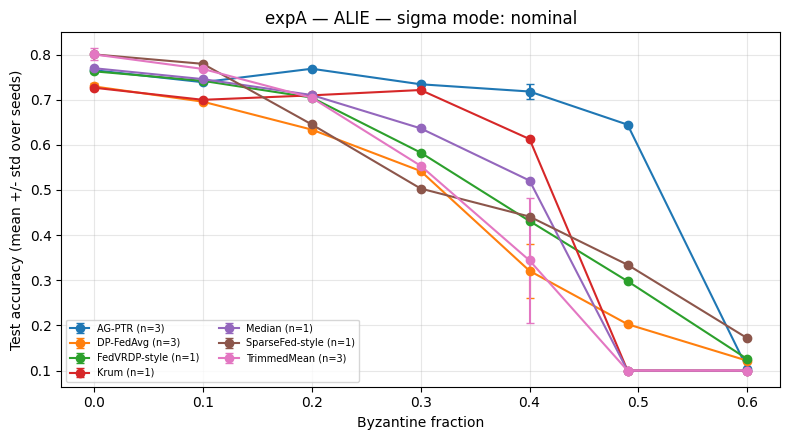

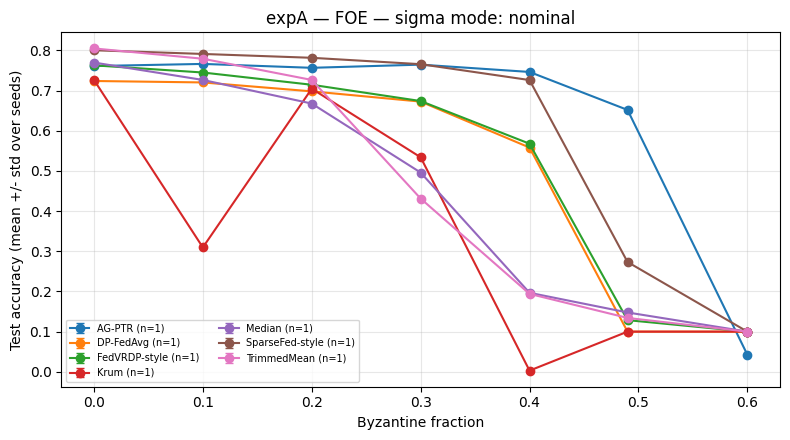

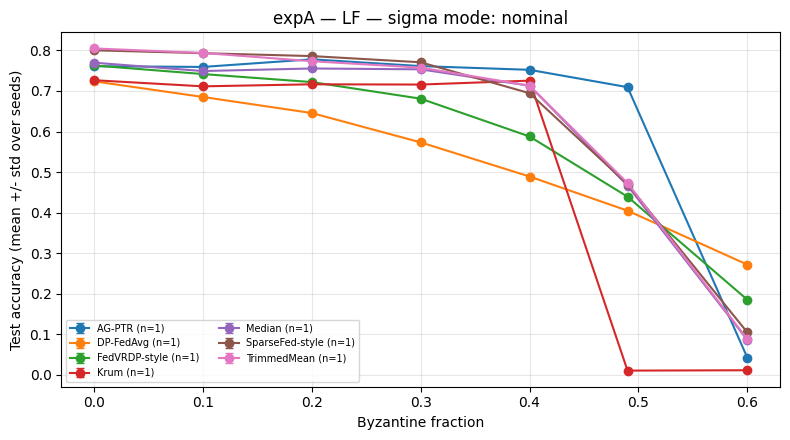

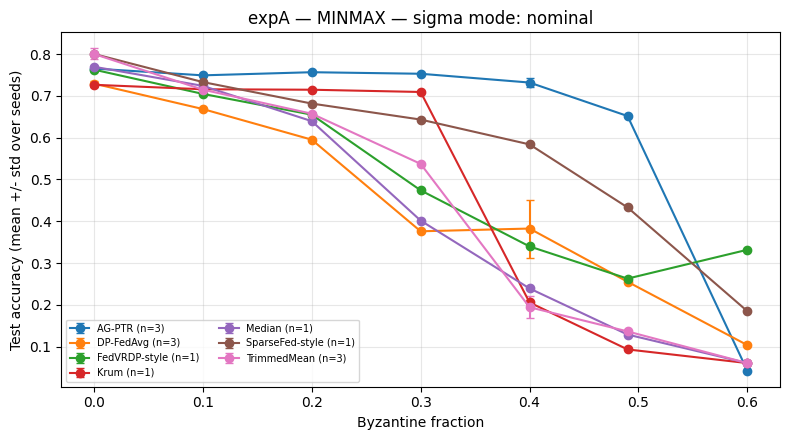

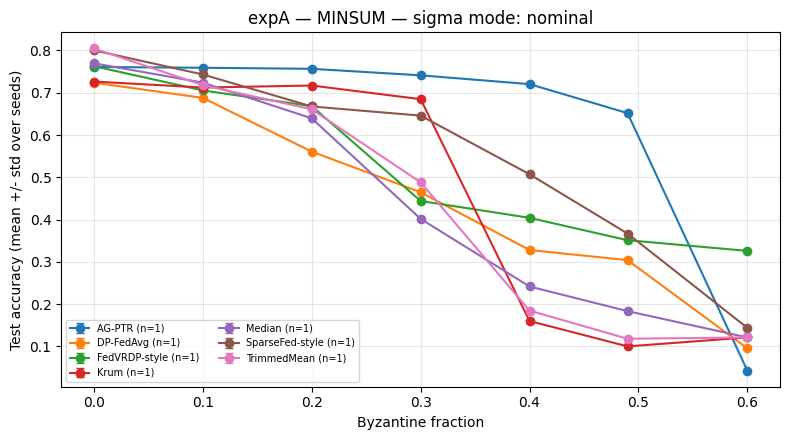

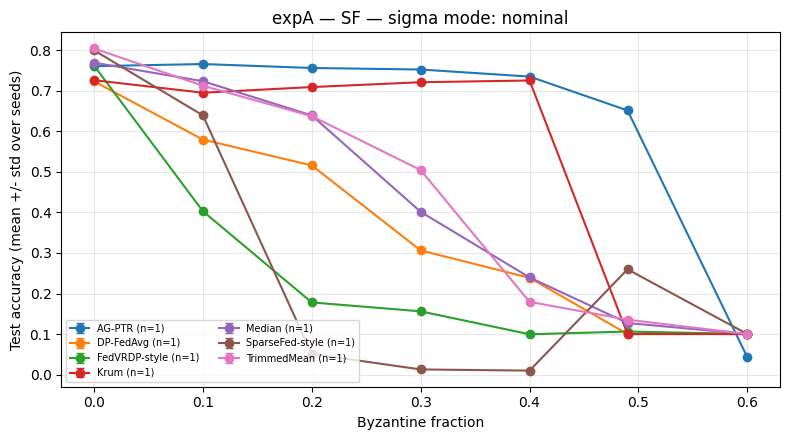

In [ ]:
# Cell 16b — JOB: seeds  (24 runs : seeds 1-2 on ALIE/MinMax, f=0/0.4, AG-PTR/DP-FedAvg/TrimmedMean)
run_job("seeds")
import_legacy("seeds")
aggregate("seeds")


JOB = certified | results file: /content/drive/MyDrive/agptr_runs/expA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR sigma mode = certified: sigma_sel = 2.1742, sigma_rel = 1.0871 | eps nominal(per-phase) = 1.576 | eps CERTIFIED(composed) = 2.000
318 runs already done, 42 to do (this cell stops after None runs; re-run it to continue)
[1/42] seed=0 ALIE    f=0.00 AG-PTR                   acc=0.7669 accept=0.972 (ok, 91s, ETA 62 min)
[2/42] seed=0 ALIE    f=0.10 AG-PTR                   acc=0.7568 accept=0.867 (ok, 86s, ETA 59 min)
[3/42] seed=0 ALIE    f=0.20 AG-PTR                   acc=0.7414 accept=0.806 (ok, 79s, ETA 55 min)
[4/42] seed=0 ALIE    f=0.30 AG-PTR                   acc=0.7483 accept=0.656 (ok, 73s, ETA 52 min)
[5/42] seed=0 ALIE    f=0.40 AG-PTR                   acc=0.7291 accept=0.411 (ok, 66s, ETA 49 min)
[6/42] seed=0 ALIE    f=0.49 AG-PTR                   acc=0.6750 accept=0.167 (ok, 59s, ETA 45 min)
[7/42] seed=0 ALIE    f=0.60 AG-PTR                   ac

,sigma_mode,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,certified,alie,ALIE,AG-PTR,0.00,0.7669,0.0,1,0.972222,NaN
1,certified,alie,ALIE,AG-PTR,0.10,0.7568,0.0,1,0.866667,NaN
2,certified,alie,ALIE,AG-PTR,0.20,0.7414,0.0,1,0.805556,NaN
3,certified,alie,ALIE,AG-PTR,0.30,0.7483,0.0,1,0.655556,NaN
4,certified,alie,ALIE,AG-PTR,0.40,0.7291,0.0,1,0.411111,NaN
...,...,...,...,...,...,...,...,...,...,...
331,nominal,sf,SF,TrimmedMean,0.20,0.6377,0.0,1,NaN,NaN
332,nominal,sf,SF,TrimmedMean,0.30,0.5046,0.0,1,NaN,NaN
333,nominal,sf,SF,TrimmedMean,0.40,0.1793,0.0,1,NaN,NaN
334,nominal,sf,SF,TrimmedMean,0.49,0.1354,0.0,1,NaN,NaN


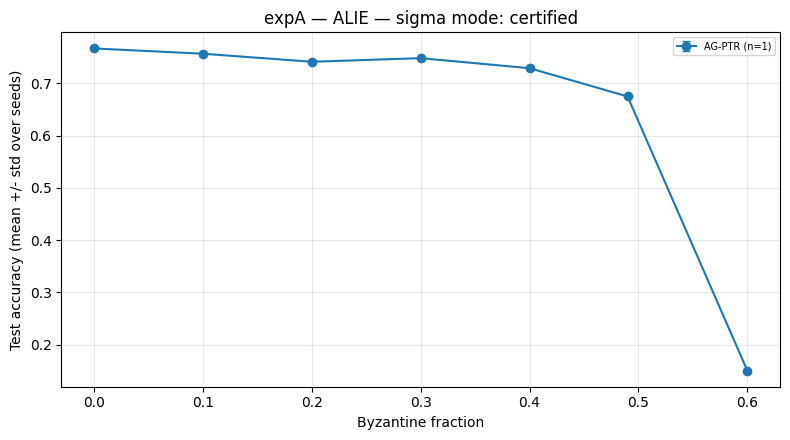

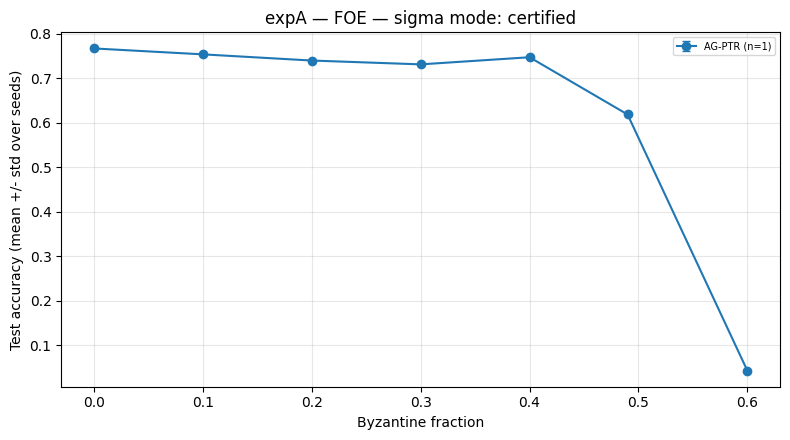

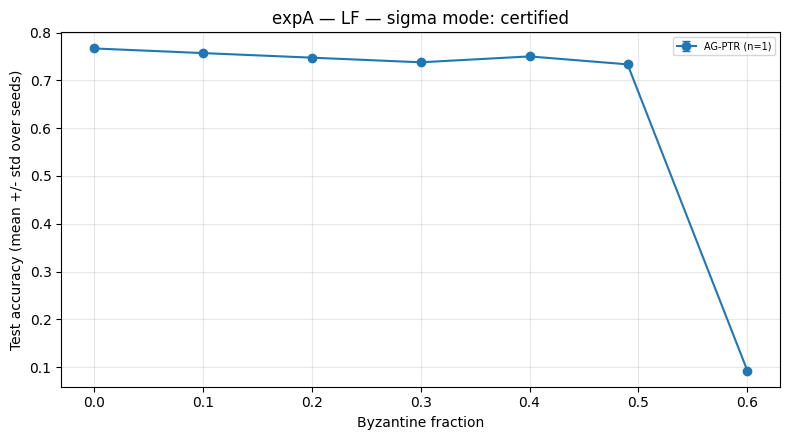

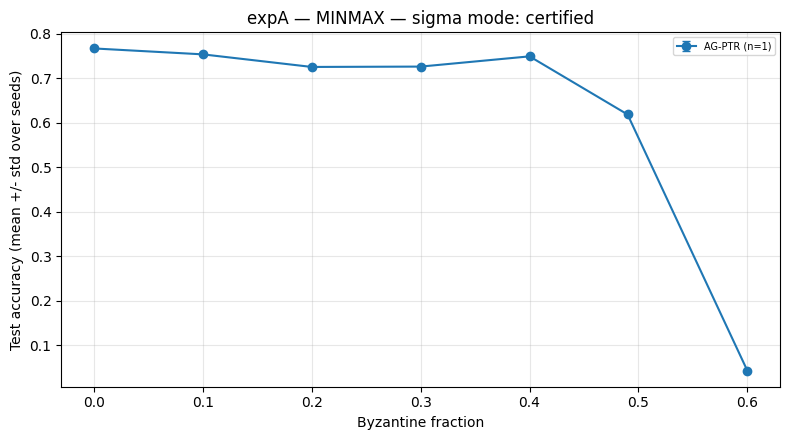

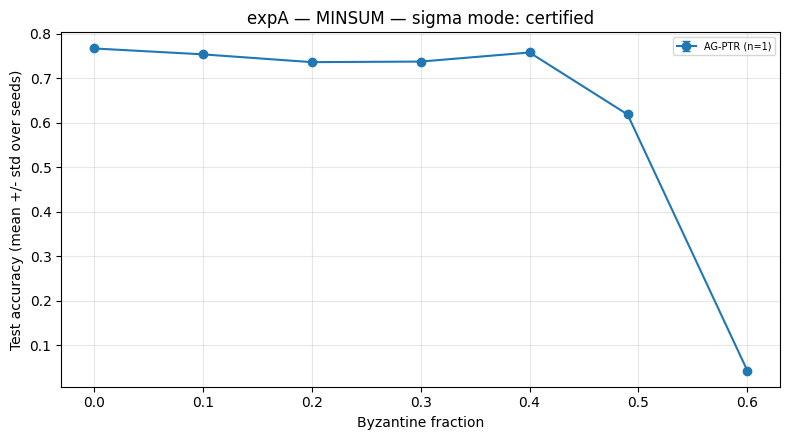

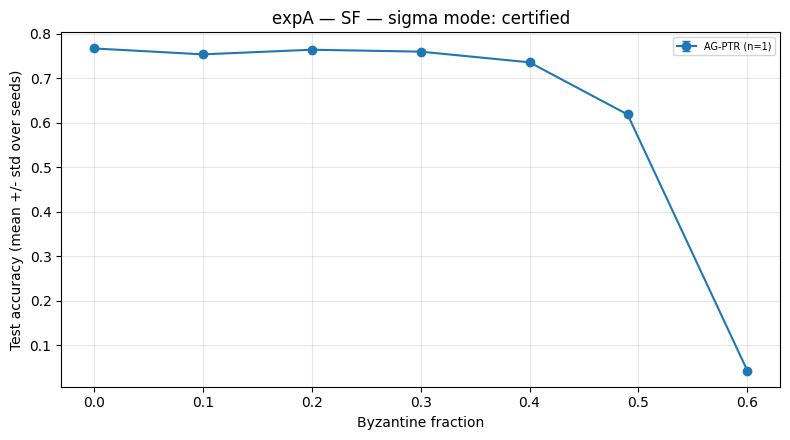

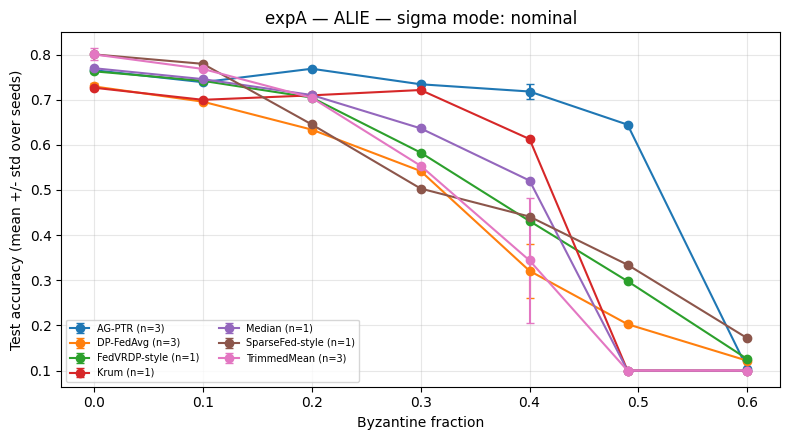

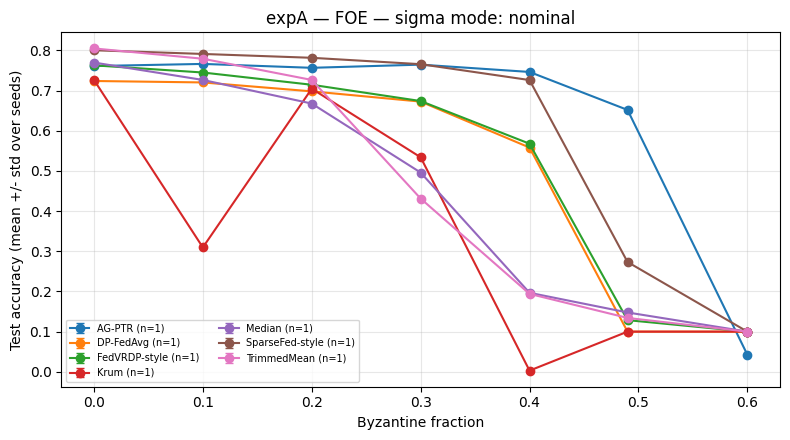

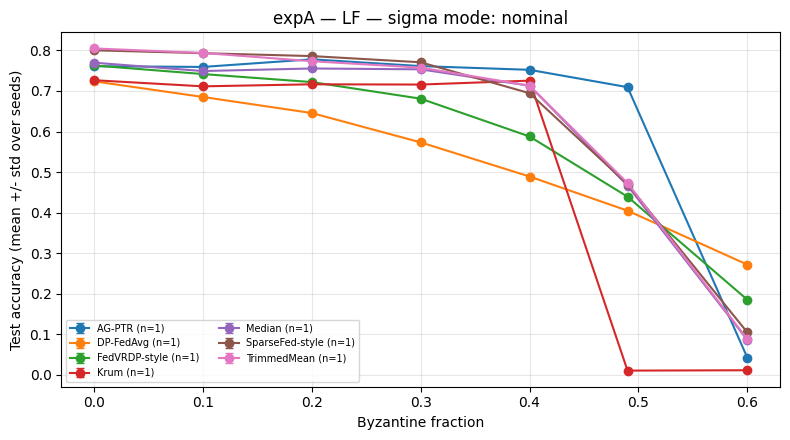

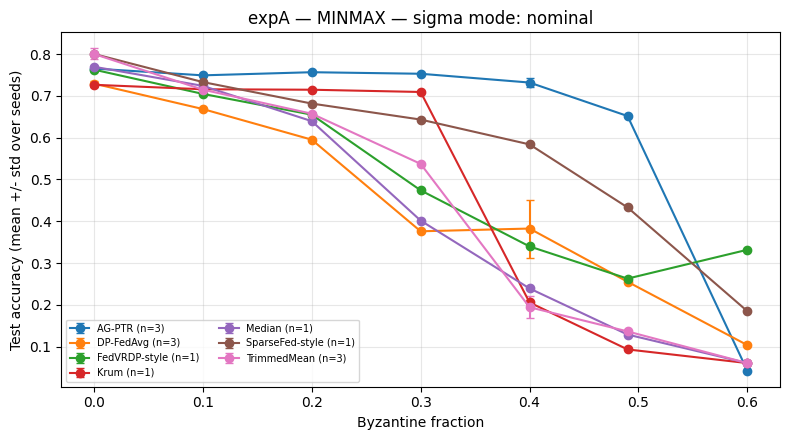

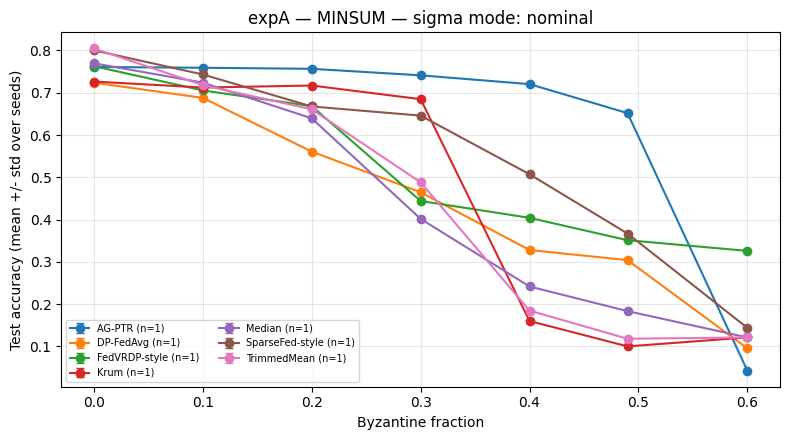

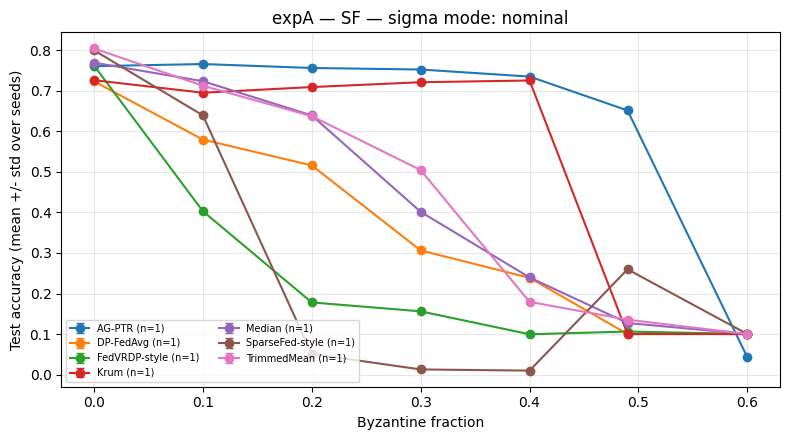

In [ ]:
# Cell 16c — JOB: certified  (42 runs : AG-PTR only, all attacks and fractions, certified eps=2 sigma)
run_job("certified")
import_legacy("certified")
aggregate("certified")


JOB = inball | results file: /content/drive/MyDrive/agptr_runs/expA_results.csv
q = 0.016722 | sigma_dp = 0.9723 | AG-PTR sigma mode = nominal: sigma_sel = 1.9659, sigma_rel = 0.9830 | eps nominal(per-phase) = 2.000 | eps CERTIFIED(composed) = 2.591
360 runs already done, 7 to do (this cell stops after None runs; re-run it to continue)
[1/7] seed=0 InBall  f=0.00 AG-PTR                   acc=0.7734 accept=0.917 (ok, 87s, ETA 9 min)
[2/7] seed=0 InBall  f=0.10 AG-PTR                   acc=0.7796 accept=0.906 (ok, 83s, ETA 7 min)
[3/7] seed=0 InBall  f=0.20 AG-PTR                   acc=0.7468 accept=0.989 (ok, 78s, ETA 6 min)
[4/7] seed=0 InBall  f=0.30 AG-PTR                   acc=0.6908 accept=0.978 (ok, 73s, ETA 4 min)
[5/7] seed=0 InBall  f=0.40 AG-PTR                   acc=0.6623 accept=1.000 (ok, 68s, ETA 3 min)
[6/7] seed=0 InBall  f=0.49 AG-PTR                   acc=0.6503 accept=1.000 (ok, 64s, ETA 1 min)
[7/7] seed=0 InBall  f=0.60 AG-PTR                   acc=0.6430 accept=1.0

,sigma_mode,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,certified,alie,ALIE,AG-PTR,0.00,0.7669,0.0,1,0.972222,NaN
1,certified,alie,ALIE,AG-PTR,0.10,0.7568,0.0,1,0.866667,NaN
2,certified,alie,ALIE,AG-PTR,0.20,0.7414,0.0,1,0.805556,NaN
3,certified,alie,ALIE,AG-PTR,0.30,0.7483,0.0,1,0.655556,NaN
4,certified,alie,ALIE,AG-PTR,0.40,0.7291,0.0,1,0.411111,NaN
...,...,...,...,...,...,...,...,...,...,...
338,nominal,sf,SF,TrimmedMean,0.20,0.6377,0.0,1,NaN,NaN
339,nominal,sf,SF,TrimmedMean,0.30,0.5046,0.0,1,NaN,NaN
340,nominal,sf,SF,TrimmedMean,0.40,0.1793,0.0,1,NaN,NaN
341,nominal,sf,SF,TrimmedMean,0.49,0.1354,0.0,1,NaN,NaN


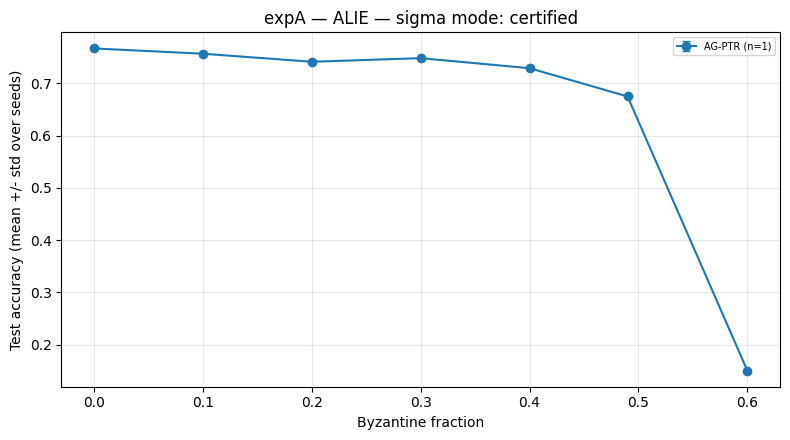

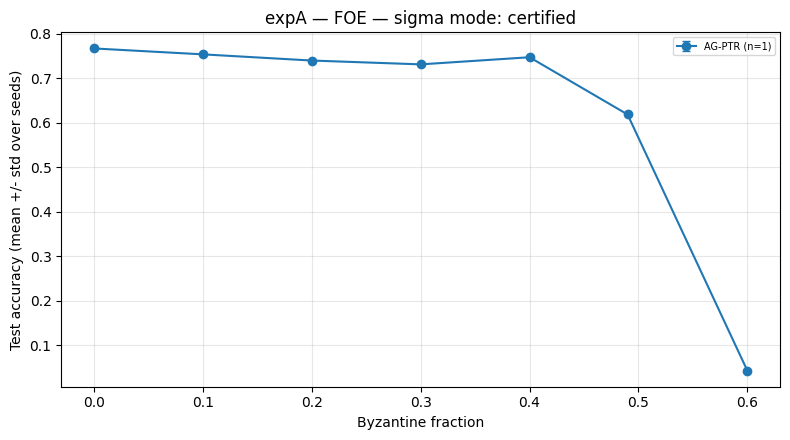

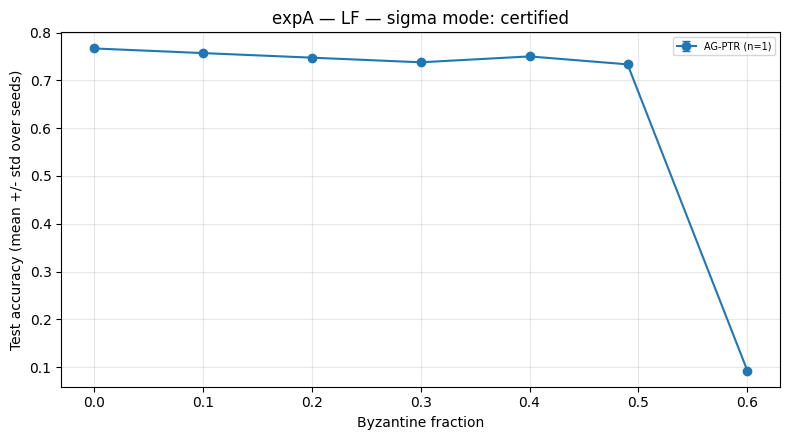

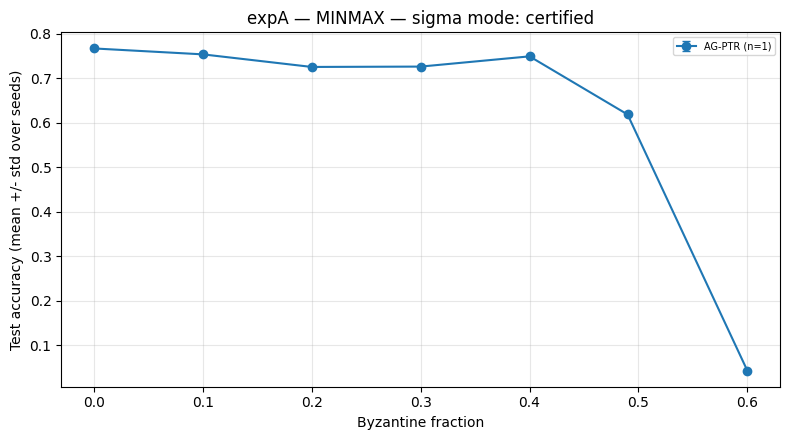

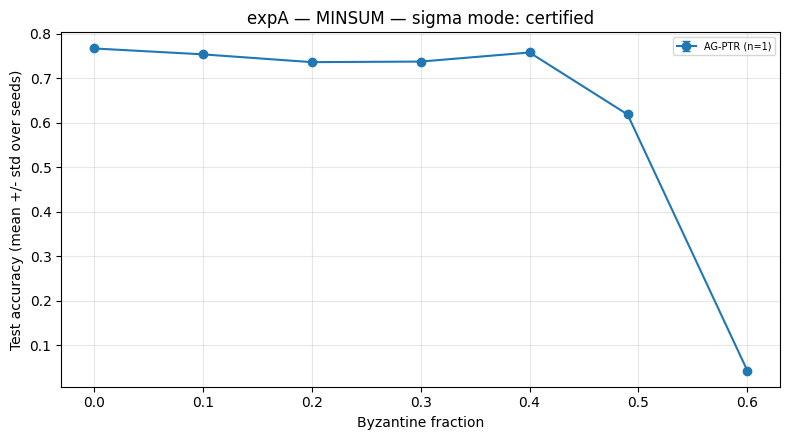

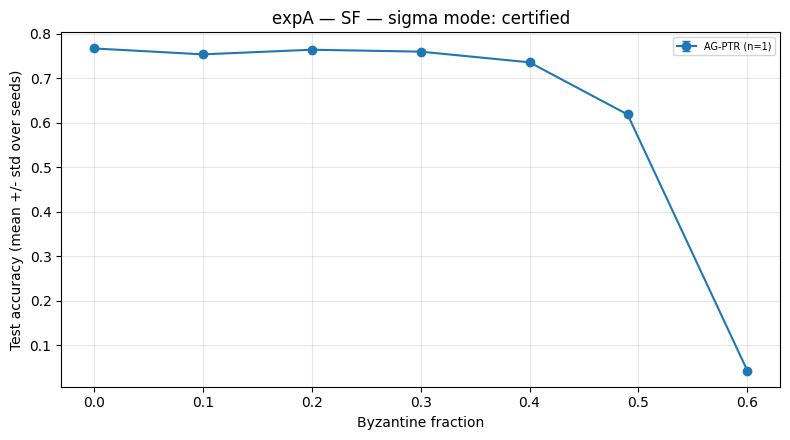

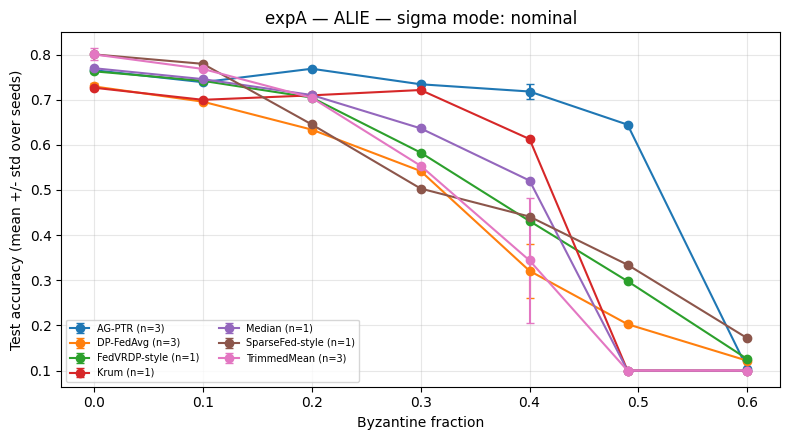

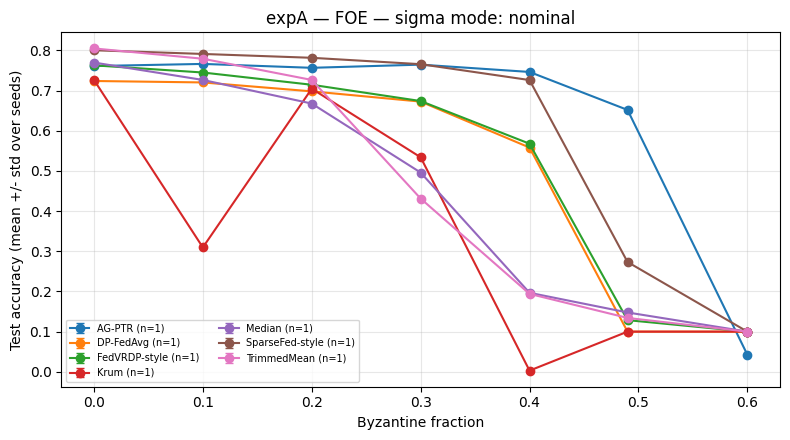

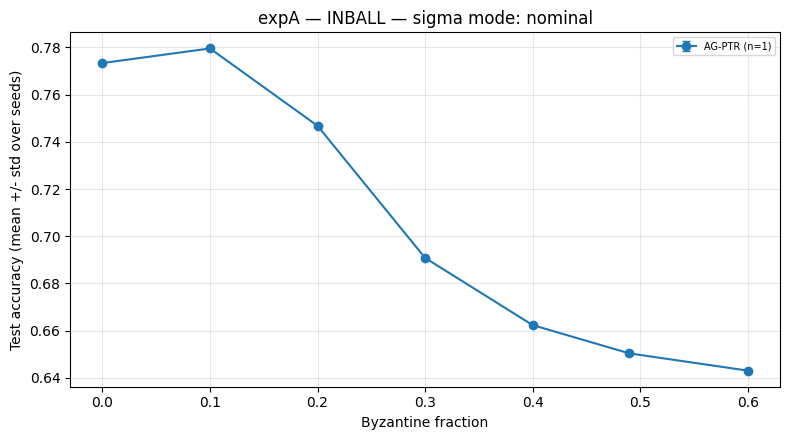

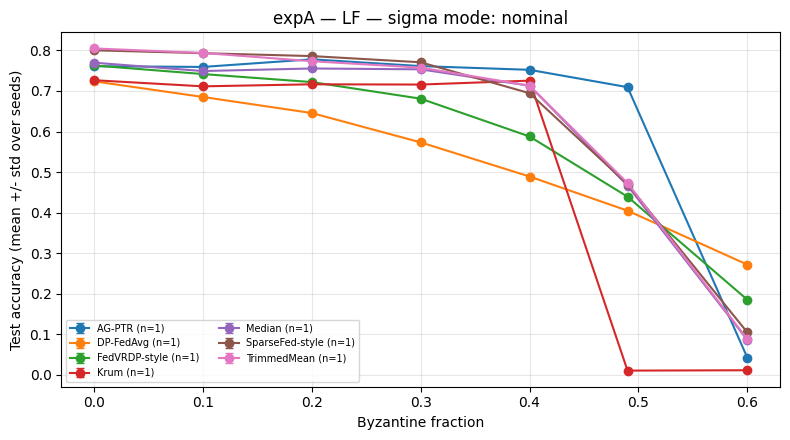

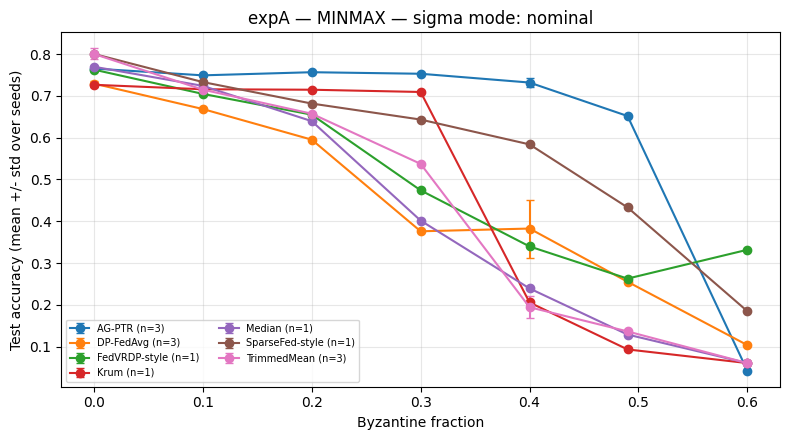

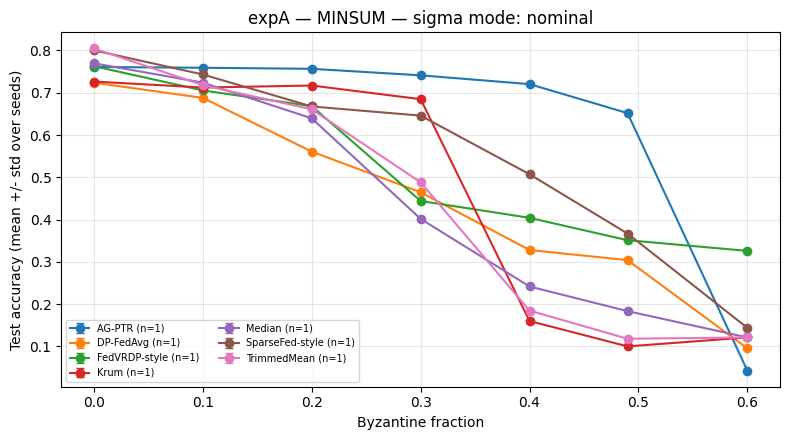

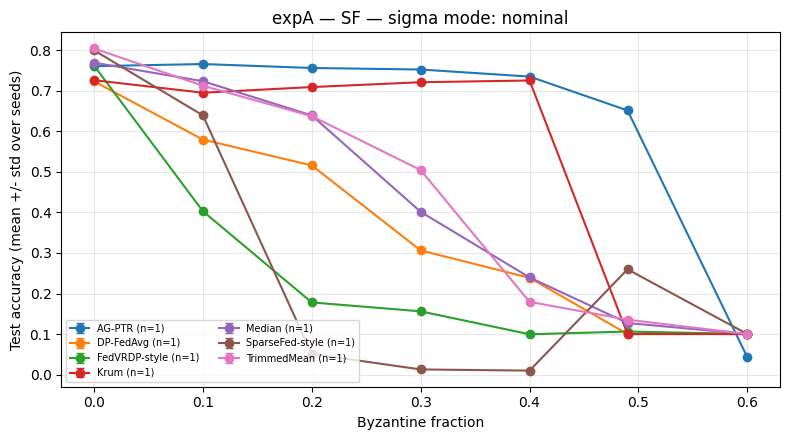

In [ ]:
# Cell 16d — JOB: inball  (7 runs : defense-aware in-ball attack against AG-PTR)
run_job("inball")
import_legacy("inball")
aggregate("inball")
